# Creative 2/6 Generation: Semantic Walk + Manifold Guidance

## Pipeline:
```
Train VAEs at dim=[16, 32, ..., 147]
    ↓
Semantic walk (vae.ipynb style) + creativity scoring → find best α
    ↓
Diffusion-guided geodesic with training data attraction
    ↓
VAE decoder → images
    ↓
Shape analysis (HOG + H1 topology)
```

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, TensorDataset

import torchvision
import torchvision.transforms as transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

try:
    import gudhi
    TOPO_AVAILABLE = True
    print('gudhi available — H1 topology enabled')
except ImportError:
    TOPO_AVAILABLE = False
    print('gudhi not found — HOG analysis only. pip install gudhi')

# ── Dims to compare (from dimension_analysis.ipynb results) ──
# Elbow at 16, reconstruction plateaus at 16, HOG balance best at 16
DIMS_TO_TEST = [16, 32, 48, 64, 96, 128, 147]
EPOCHS       = 50
HIDDEN_DIM   = 400
BATCH_SIZE   = 128
N_WALK_STEPS = 20       # waypoints along geodesic

Device: cuda
gudhi available — H1 topology enabled


---
## Definitions

In [46]:
# ─────────────────────────────────────────────────────────────
# Data
# ─────────────────────────────────────────────────────────────

def get_mnist_26(batch_size=128, train=True):
    dataset = torchvision.datasets.MNIST(
        'data', train=train, download=True, transform=transforms.ToTensor())
    mask = (dataset.targets == 2) | (dataset.targets == 6)
    return DataLoader(Subset(dataset, torch.where(mask)[0]),
                      batch_size=batch_size, shuffle=train)

def cache_flat_labeled(loader):
    xs, ys = [], []
    for x, y in loader:
        xs.append(x.view(x.size(0),-1).numpy()); ys.append(y.numpy())
    return np.concatenate(xs), np.concatenate(ys)

train_loader = get_mnist_26(BATCH_SIZE, True)
test_loader  = get_mnist_26(BATCH_SIZE, False)
train_flat, train_labels = cache_flat_labeled(train_loader)
rng       = np.random.default_rng(0)
train_sub = train_flat[rng.choice(len(train_flat), 2000, replace=False)]
print(f'Training images: {len(train_flat)}')

Training images: 11876


In [47]:
# ─────────────────────────────────────────────────────────────
# VAE — exactly as vae.ipynb (hidden_dim=400, single hidden layer)
# decode() method name matches vae.ipynb interface
# ─────────────────────────────────────────────────────────────

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=147):
        super().__init__()
        self.latent_dim  = latent_dim
        self.hidden_dim  = hidden_dim
        self.encoder = nn.Sequential(
            nn.Flatten(), nn.Linear(input_dim, hidden_dim), nn.ReLU())
        self.fc_mu     = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, input_dim), nn.Sigmoid())

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5*logvar) * torch.randn_like(mu)

    def decode(self, z):
        """Decode z → (B,1,28,28). Matches vae.ipynb interface."""
        return self.decoder_net(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, lv = self.encode(x)
        return self.decode(self.reparameterize(mu, lv)), mu, lv


def vae_loss(recon, x, mu, lv):
    bce = F.binary_cross_entropy(recon, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + lv - mu.pow(2) - lv.exp())
    return bce + kld


def train_vae(latent_dim, hidden_dim=400, epochs=30, device='cpu'):
    model = VAE(latent_dim=latent_dim, hidden_dim=hidden_dim).to(device)
    opt   = optim.Adam(model.parameters(), lr=1e-3)
    train_losses, test_losses = [], []
    for epoch in range(epochs):
        model.train()
        total = 0.0
        for x, _ in train_loader:
            x = x.to(device)
            recon, mu, lv = model(x)
            loss = vae_loss(recon, x, mu, lv)
            opt.zero_grad(); loss.backward(); opt.step()
            total += loss.item()
        train_losses.append(total / len(train_loader.dataset))
        model.eval()
        total = 0.0
        with torch.no_grad():
            for x, _ in test_loader:
                x = x.to(device)
                recon, mu, lv = model(x)
                total += vae_loss(recon, x, mu, lv).item()
        test_losses.append(total / len(test_loader.dataset))
        if (epoch+1) % 10 == 0:
            print(f'  [VAE dim={latent_dim}] epoch {epoch+1}/{epochs}  '
                  f'train={train_losses[-1]:.2f}  test={test_losses[-1]:.2f}')
    model.eval()
    return model, train_losses, test_losses

In [48]:
# ─────────────────────────────────────────────────────────────
# Classifier, GeneralAE, creativity metric
# ─────────────────────────────────────────────────────────────

class Classifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(784,256), nn.ReLU(),
            nn.Linear(256,64), nn.ReLU(), nn.Linear(64,2))
    def forward(self, x): return self.net(x)
    def probs(self, x):   return F.softmax(self.forward(x), dim=1)


class GeneralAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        self.enc = nn.Sequential(nn.Flatten(), nn.Linear(784,256), nn.ReLU(), nn.Linear(256,latent_dim))
        self.dec = nn.Sequential(nn.Linear(latent_dim,256), nn.ReLU(),
                                  nn.Linear(256,784), nn.Sigmoid(), nn.Unflatten(1,(1,28,28)))
    def forward(self, x): return self.dec(self.enc(x))


def js_ambiguity(probs):
    u=np.full_like(probs,0.5); m=0.5*(probs+u); eps=1e-10
    return np.clip(0.5*np.sum(probs*np.log2((probs+eps)/(m+eps)),1) +
                   0.5*np.sum(u*np.log2((u+eps)/(m+eps)),1), 0., 1.)

def js_ambiguity_torch(probs):
    u=torch.full_like(probs,0.5); m=0.5*(probs+u); eps=1e-10
    return torch.clamp(0.5*(probs*torch.log2((probs+eps)/(m+eps))).sum(1) +
                       0.5*(u*torch.log2((u+eps)/(m+eps))).sum(1), 0., 1.)

def score_creativity_extended(images, clf, gen_ae, ref_flat, device='cpu'):
    clf.eval(); gen_ae.eval()
    with torch.no_grad():
        imgs  = images.to(device)
        recon = gen_ae(imgs)
        mse   = F.mse_loss(recon, imgs, reduction='none').mean(dim=[1,2,3]).cpu().numpy()
        probs = clf.probs(imgs).cpu().numpy()
    realness  = 1.0 / (1.0 + mse)
    ambiguity = js_ambiguity(probs)
    flat      = images.view(images.size(0),-1).cpu().numpy()
    nn_dist   = NearestNeighbors(n_neighbors=1).fit(ref_flat).kneighbors(flat)[0][:,0]
    novelty   = nn_dist / (1.0 + nn_dist)
    # Gate: only reward genuine mixtures where classifier is actually confused
    # A=0.31 was being rewarded — we want A closer to 0.5 (true 50/50 confusion)
    ambiguity_gated = np.where(ambiguity > 0.40, ambiguity, ambiguity * 0.1)
    creativity = (novelty**(1/3)) * (realness**(1/3)) * (ambiguity_gated**(1/3))
    return creativity, novelty, realness, ambiguity   # return raw ambiguity for inspection


# Train shared components
print('Training Classifier...')
clf     = Classifier().to(device)
opt_clf = optim.Adam(clf.parameters(), lr=1e-3)
clf.train()
for epoch in range(10):
    for x,y in train_loader:
        x=x.to(device); y=(y==6).long().to(device)
        loss=F.cross_entropy(clf(x),y)
        opt_clf.zero_grad(); loss.backward(); opt_clf.step()
clf.eval()
# Accuracy check
correct, n = 0, 0
with torch.no_grad():
    for x,y in test_loader:
        x=x.to(device); y=(y==6).long().to(device)
        correct+=(clf(x).argmax(1)==y).sum().item(); n+=y.size(0)
print(f'Classifier accuracy: {correct/n:.4f}')

print('Training GeneralAE on all 10 MNIST digits...')
full_loader = DataLoader(
    torchvision.datasets.MNIST('data',True,download=True,transform=transforms.ToTensor()),
    batch_size=256, shuffle=True)
gen_ae  = GeneralAE(64).to(device)
opt_ae  = optim.Adam(gen_ae.parameters(), lr=1e-3)
gen_ae.train()
for epoch in range(10):
    for x,_ in full_loader:
        x=x.to(device); loss=F.mse_loss(gen_ae(x),x)
        opt_ae.zero_grad(); loss.backward(); opt_ae.step()
gen_ae.eval()
print('Done.')

Training Classifier...
Classifier accuracy: 0.9955
Training GeneralAE on all 10 MNIST digits...
Done.


In [49]:
# ─────────────────────────────────────────────────────────────
# Latent Denoiser (for diffusion guidance in latent space)
# ─────────────────────────────────────────────────────────────

class SinusoidalTimeEmbed(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half  = self.dim // 2
        freqs = torch.exp(-torch.arange(half, device=t.device) *
                          (np.log(10000) / max(half-1,1)))
        args  = t[:,None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)

class LatentDenoiser(nn.Module):
    def __init__(self, latent_dim=32, hidden=512, time_dim=128):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalTimeEmbed(time_dim), nn.Linear(time_dim,time_dim), nn.SiLU())
        self.net = nn.Sequential(
            nn.Linear(latent_dim+time_dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden),               nn.SiLU(),
            nn.Linear(hidden, hidden),               nn.SiLU(),
            nn.Linear(hidden, latent_dim))
    def forward(self, z, t, cond=None):
        return self.net(torch.cat([z, self.time_embed(t)], dim=-1))

class DDPMScheduler:
    def __init__(self, T=500, beta_start=1e-4, beta_end=0.02):
        self.T               = T
        self.betas           = torch.linspace(beta_start, beta_end, T)
        self.alphas          = 1.0 - self.betas
        self.alpha_bars      = torch.cumprod(self.alphas, dim=0)
        self.alpha_bars_prev = torch.cat([torch.tensor([1.0]), self.alpha_bars[:-1]])
    def to(self, device):
        for attr in ['betas','alphas','alpha_bars','alpha_bars_prev']:
            setattr(self, attr, getattr(self, attr).to(device))
        return self
    def q_sample(self, x0, t, noise=None):
        if noise is None: noise = torch.randn_like(x0)
        ab = self.alpha_bars[t].view(-1, *([1]*(x0.dim()-1)))
        return torch.sqrt(ab)*x0 + torch.sqrt(1-ab)*noise, noise
    def denoise_score(self, denoiser, z, t_frac=0.05):
        t_int    = max(1, int(t_frac * self.T))
        t_tensor = torch.full((z.size(0),), t_int, device=z.device, dtype=torch.long)
        with torch.no_grad():
            eps_pred = denoiser(z, t_tensor)
        ab = self.alpha_bars[t_int]
        return -eps_pred / (torch.sqrt(1-ab) + 1e-8)

print('Architecture definitions ready.')

Architecture definitions ready.


---
## Train VAEs at Multiple Dimensions
Training dim=16, 32, and 147. From dimension_analysis: elbow at 16, reconstruction plateaus at 16,
ambiguity saturates by dim=32. 147 included as the full PCA baseline.

In [50]:
# ─────────────────────────────────────────────────────────────
# Train VAEs and latent denoisers for each dimension
# ─────────────────────────────────────────────────────────────

vaes       = {}   # dim → VAE model
denoisers  = {}   # dim → LatentDenoiser
schedulers = {}   # dim → DDPMScheduler

for dim in DIMS_TO_TEST:
    print(f'\n── dim={dim} ──────────────────────────────────')

    # Train VAE
    vae, tl, vl = train_vae(dim, HIDDEN_DIM, EPOCHS, device)
    vaes[dim]   = vae

    # Encode training set to latent codes
    all_mus, all_labels = [], []
    with torch.no_grad():
        for x, y in train_loader:
            mu, _ = vae.encode(x.to(device))
            all_mus.append(mu.cpu()); all_labels.append(y)
    latent_mus    = torch.cat(all_mus)
    latent_labels = torch.cat(all_labels)

    # Train latent DDPM
    sched     = DDPMScheduler(T=500).to(device)
    denoiser  = LatentDenoiser(latent_dim=dim, hidden=512, time_dim=128).to(device)
    opt_ld    = optim.Adam(denoiser.parameters(), lr=2e-4)
    sched_ld  = optim.lr_scheduler.CosineAnnealingLR(opt_ld, T_max=150)
    lat_loader = DataLoader(TensorDataset(latent_mus, latent_labels),
                             batch_size=256, shuffle=True)
    denoiser.train()
    for epoch in range(125):
        total = 0.0
        for z, _ in lat_loader:
            z = z.to(device)
            t = torch.randint(0, sched.T, (z.size(0),), device=device)
            z_noisy, noise = sched.q_sample(z, t)
            loss = F.mse_loss(denoiser(z_noisy, t), noise)
            opt_ld.zero_grad(); loss.backward(); opt_ld.step()
            total += loss.item()
        sched_ld.step()
        if (epoch+1) % 50 == 0:
            print(f'  [Denoiser dim={dim}] epoch {epoch+1}/150  loss={total/len(lat_loader):.6f}')
    denoiser.eval()
    denoisers[dim]  = denoiser
    schedulers[dim] = sched

    # Store latent codes and training latents tensor for this dim
    vaes[dim]._latent_mus    = latent_mus
    vaes[dim]._latent_labels = latent_labels
    vaes[dim]._train_latents = latent_mus.to(device)

print('\nAll VAEs and denoisers trained.')


── dim=16 ──────────────────────────────────
  [VAE dim=16] epoch 10/30  train=116.20  test=116.05
  [VAE dim=16] epoch 20/30  train=109.97  test=111.22
  [VAE dim=16] epoch 30/30  train=107.51  test=109.27
  [Denoiser dim=16] epoch 50/150  loss=0.382386
  [Denoiser dim=16] epoch 100/150  loss=0.368106
  [Denoiser dim=16] epoch 150/150  loss=0.374248

── dim=32 ──────────────────────────────────
  [VAE dim=32] epoch 10/30  train=118.87  test=118.71
  [VAE dim=32] epoch 20/30  train=110.82  test=112.00
  [VAE dim=32] epoch 30/30  train=107.99  test=109.81
  [Denoiser dim=32] epoch 50/150  loss=0.282879
  [Denoiser dim=32] epoch 100/150  loss=0.279321
  [Denoiser dim=32] epoch 150/150  loss=0.278681

── dim=48 ──────────────────────────────────
  [VAE dim=48] epoch 10/30  train=120.99  test=120.35
  [VAE dim=48] epoch 20/30  train=111.33  test=112.31
  [VAE dim=48] epoch 30/30  train=108.15  test=109.57
  [Denoiser dim=48] epoch 50/150  loss=0.207370
  [Denoiser dim=48] epoch 100/150  l

---
## Section 1 — Semantic Walk

Anchor on a real digit-2, walk in the 2→6 direction. The key finding from the image you shared: α=1.0–2.0 (past class-6 centroid) gives the most creative-looking images.

We run this at each latent dimension and score every step with the creativity metric.

In [62]:
# ─────────────────────────────────────────────────────────────
# Semantic walk — exactly as vae.ipynb
# Anchor: first class-2 in test set
# Direction: normalized (mu6_centroid - mu2_centroid)
# Step size: std of projections of all training points onto direction
# ─────────────────────────────────────────────────────────────

def semantic_walk(vae, alphas, device):
    """
    Replicates vae.ipynb semantic walk exactly.
    Returns latent points and decoded images along the walk.
    """
    vae.eval()
    latent_mus    = vae._latent_mus
    latent_labels = vae._latent_labels

    mu2_all = latent_mus[latent_labels == 2]
    mu6_all = latent_mus[latent_labels == 6]
    mu2_centroid = mu2_all.mean(0)
    mu6_centroid = mu6_all.mean(0)

    # Normalized semantic direction
    direction_sem = mu6_centroid - mu2_centroid
    direction_sem = direction_sem / (direction_sem.norm() + 1e-8)

    # Anchor: real 2 whose latent code is CLOSEST to any 6
    # This finds the most 6-like 2 in the training set — the pair
    # most likely to produce a clean visual mixture when interpolated
    dists_cross = torch.cdist(mu2_all.unsqueeze(0), mu6_all.unsqueeze(0)).squeeze(0)
    best_2_idx  = dists_cross.min(dim=1).values.argmin().item()
    best_6_idx  = dists_cross.min(dim=0).values.argmin().item()
    z_anchor    = mu2_all[best_2_idx]          # most 6-like digit 2
    z_target    = mu6_all[best_6_idx]          # most 2-like digit 6
    
    # Step size: distance between this specific pair
    step = (z_target - z_anchor).norm().item() / 4.0

    # Calibrate step size: std of projections (matches vae.ipynb)
    mu_all = torch.cat([mu2_all, mu6_all])
    proj   = (mu_all - z_anchor) @ direction_sem
    step   = proj.std().item()
    step   = max(step, 0.5)   # floor as in vae.ipynb

    # Build walk: z = z_anchor + alpha * step * direction
    # New: interpolate directly between the real pair
    z_walk = torch.stack(
        [(1 - (a.item()+2)/4) * z_anchor + ((a.item()+2)/4) * z_target
         for a in alphas]).to(device)
    
    with torch.no_grad():
        imgs_walk = vae.decode(z_walk).cpu()

    return z_walk, imgs_walk, direction_sem, z_anchor, step


# Run semantic walk at each dimension — wide alpha range to capture vae.ipynb result
alphas_wide = torch.tensor([-10.0, -8.5, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.5, 10.0])

walk_results = {}
for dim in DIMS_TO_TEST:
    z_w, imgs_w, dir_sem, z_anc, step = semantic_walk(vaes[dim], alphas_wide, device)
    c, n, r, a = score_creativity_extended(imgs_w, clf, gen_ae, train_sub, device)
    walk_results[dim] = {
        'z': z_w, 'imgs': imgs_w, 'c': c, 'r': r, 'a': a,
        'direction': dir_sem, 'anchor': z_anc, 'step': step
    }
    best_alpha = alphas_wide[c.argmax()].item()
    print(f'dim={dim:<4}  best α={best_alpha:+.1f}  C={c.max():.4f}  '
          f'R={r[c.argmax()]:.4f}  A={a[c.argmax()]:.4f}')

dim=16    best α=-10.0  C=0.2961  R=0.9980  A=0.3044
dim=32    best α=-10.0  C=0.2969  R=0.9937  A=0.3113
dim=48    best α=-10.0  C=0.3017  R=0.9928  A=0.3106
dim=64    best α=-3.0  C=0.2962  R=0.9979  A=0.3112
dim=96    best α=-10.0  C=0.2952  R=0.9977  A=0.3113
dim=128   best α=-4.0  C=0.2948  R=0.9983  A=0.3109
dim=147   best α=-3.0  C=0.2958  R=0.9976  A=0.3112


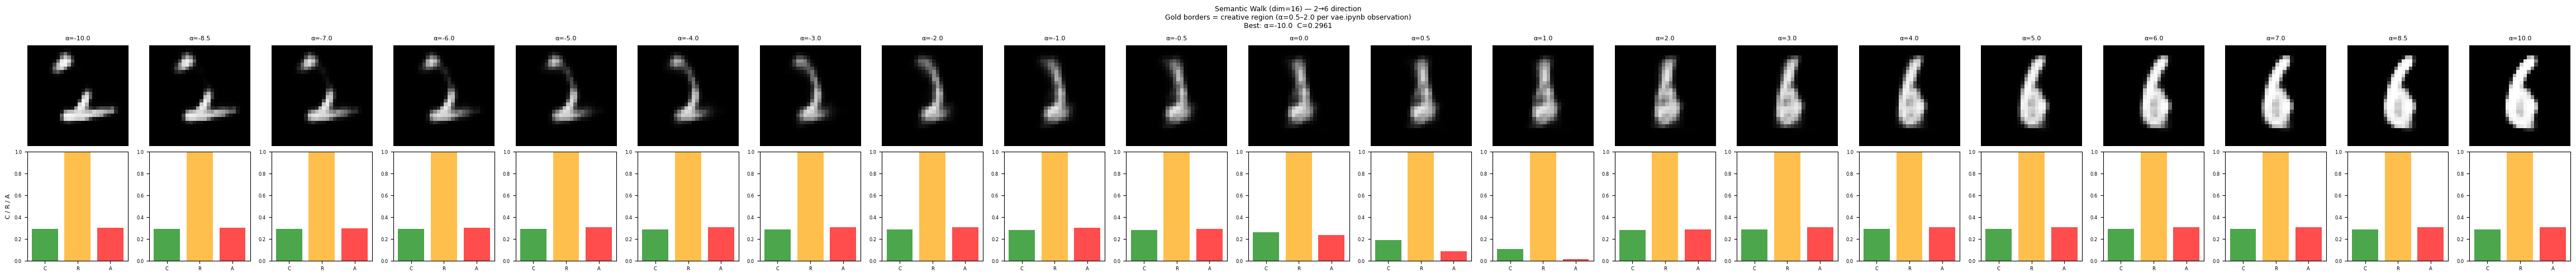

Saved -> semantic_walk_dim16.png


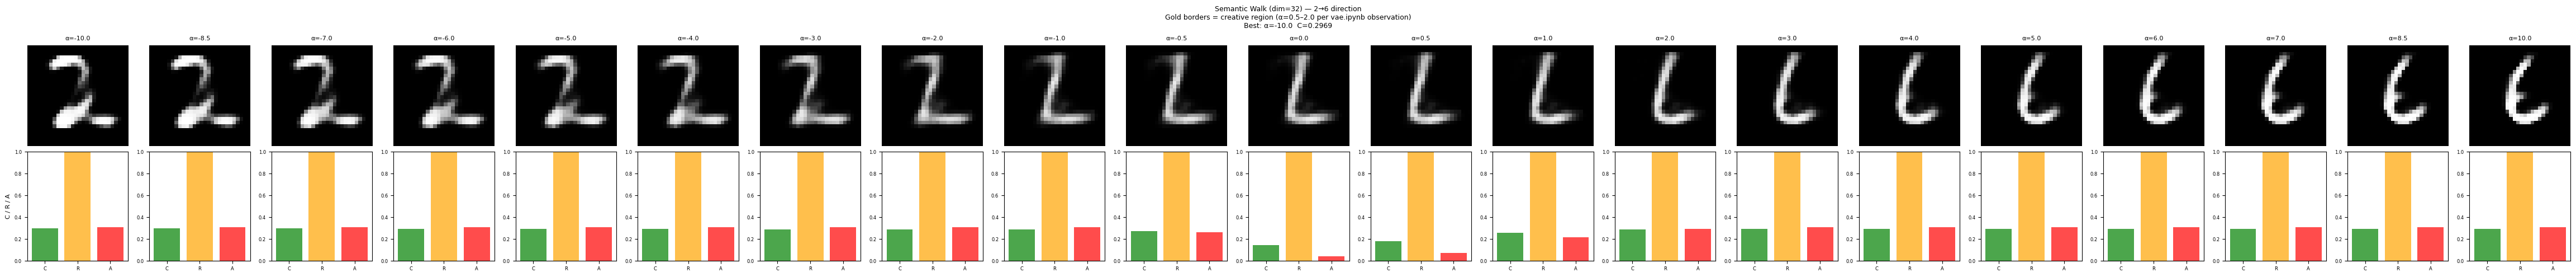

Saved -> semantic_walk_dim32.png


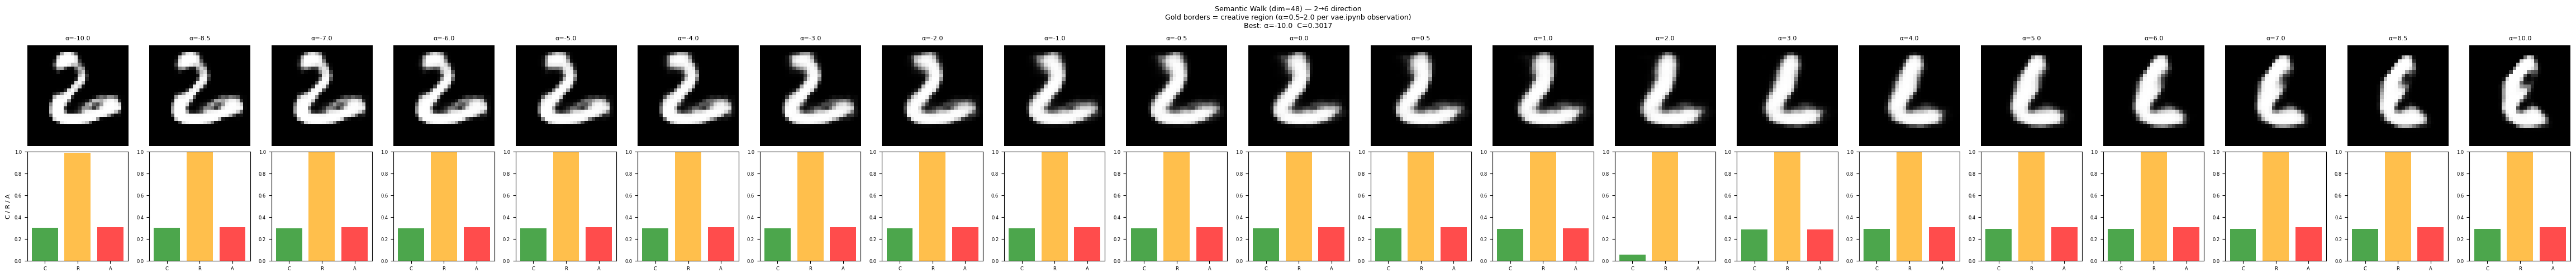

Saved -> semantic_walk_dim48.png


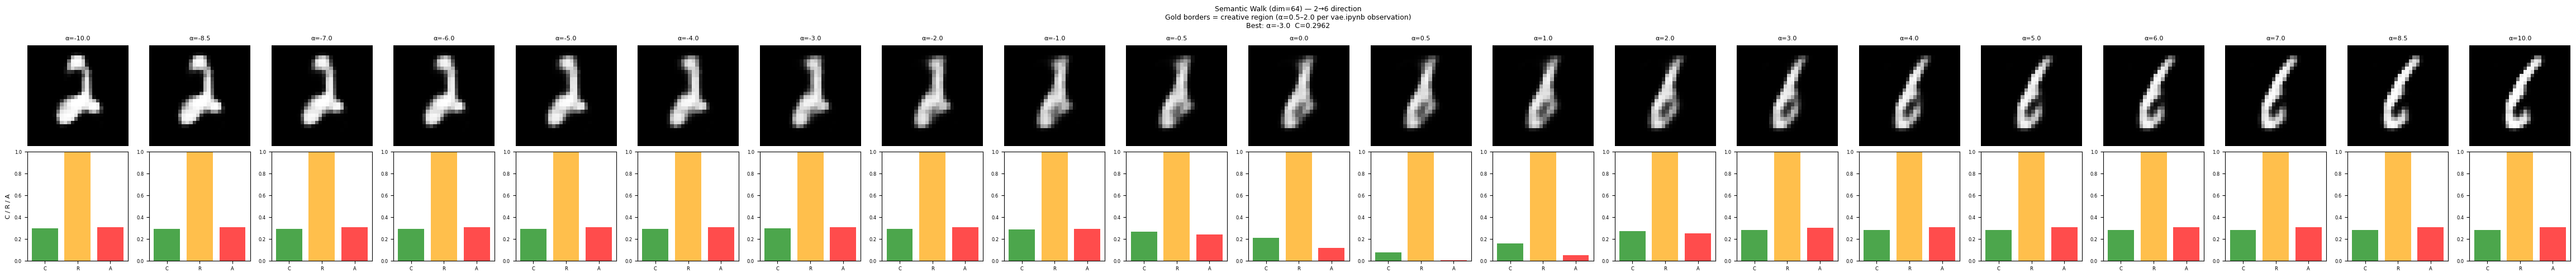

Saved -> semantic_walk_dim64.png


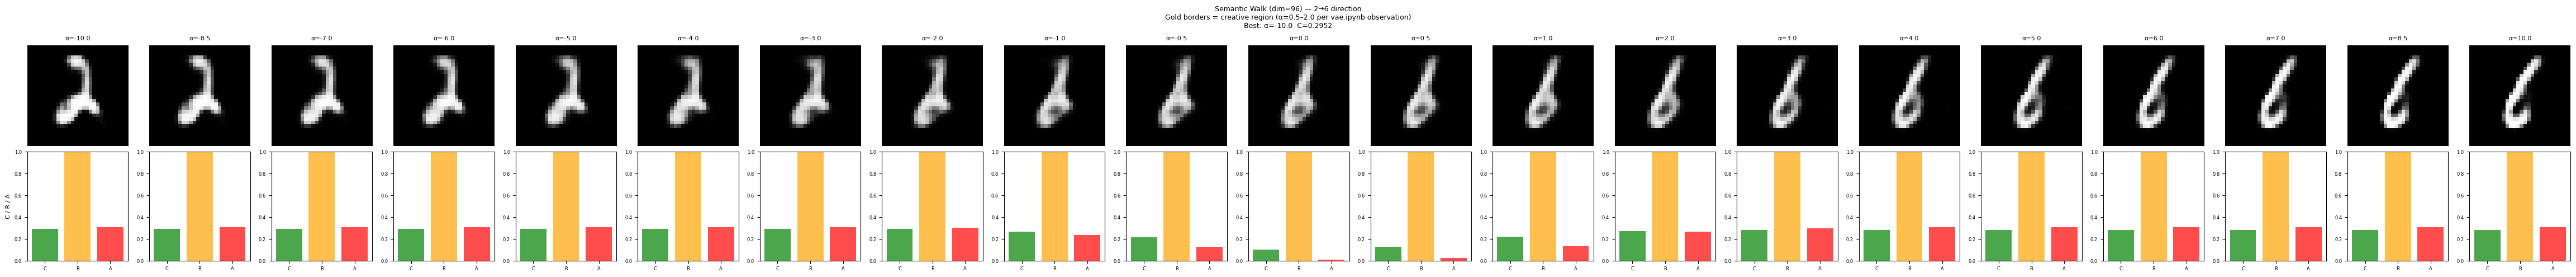

Saved -> semantic_walk_dim96.png


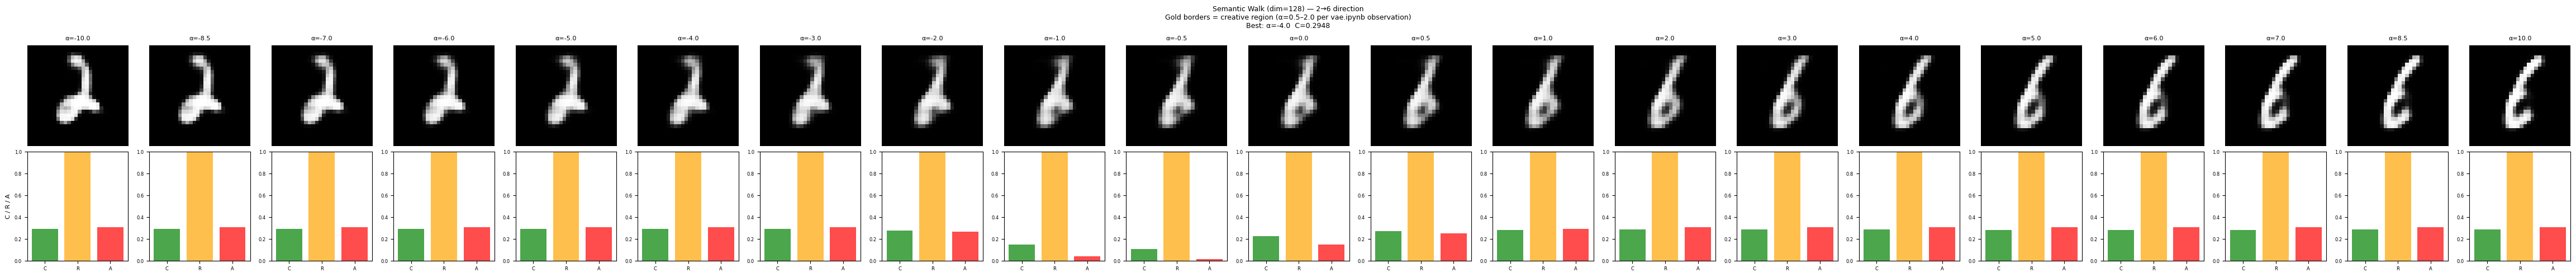

Saved -> semantic_walk_dim128.png


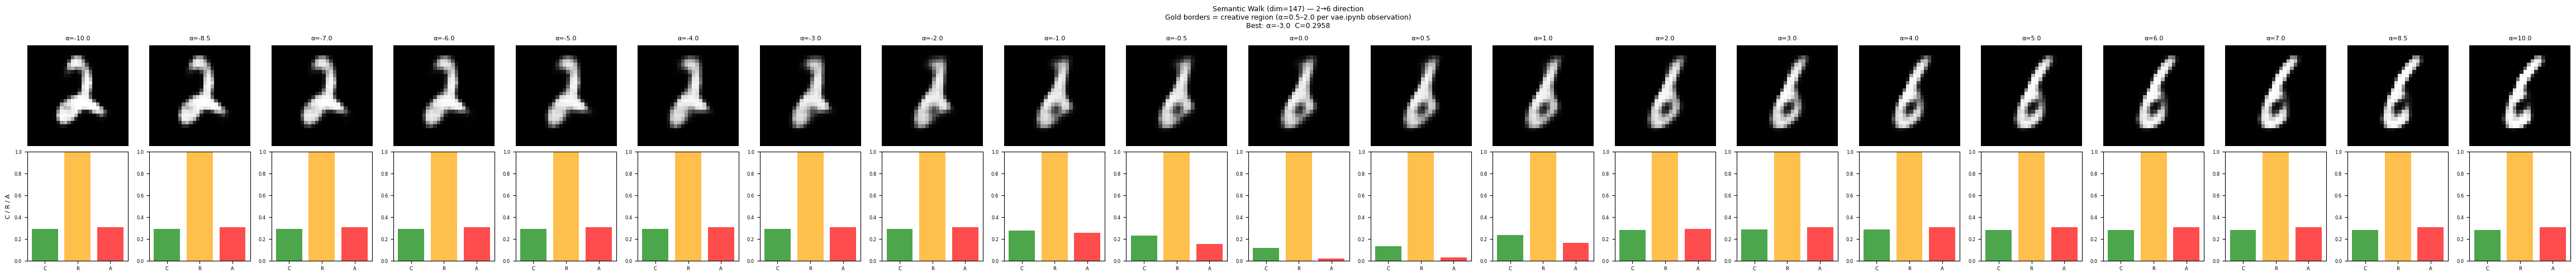

Saved -> semantic_walk_dim147.png


In [63]:
# ─────────────────────────────────────────────────────────────
# Plot: replicate vae.ipynb visualization at each dimension
# Shows semantic walk + creativity scores at each alpha
# ─────────────────────────────────────────────────────────────

n_alphas = len(alphas_wide)

for dim in DIMS_TO_TEST:
    wr   = walk_results[dim]
    imgs = wr['imgs']; c = wr['c']; a = wr['a']

    fig, axes = plt.subplots(2, n_alphas, figsize=(2.2*n_alphas, 5))
    for i, alpha in enumerate(alphas_wide):
        axes[0][i].imshow(imgs[i,0], cmap='gray', vmin=0, vmax=1)
        axes[0][i].set_title(f'α={alpha.item():.1f}', fontsize=8)
        axes[0][i].axis('off')
        # Highlight creative region (matches what vae.ipynb image shows)
        if 0.5 <= alpha.item() <= 2.0:
            for spine in axes[0][i].spines.values():
                spine.set_edgecolor('gold'); spine.set_linewidth(3); spine.set_visible(True)

        axes[1][i].bar(['C','R','A'], [c[i], wr['r'][i], a[i]],
                        color=['green','orange','red'], alpha=0.7)
        axes[1][i].set_ylim(0,1); axes[1][i].tick_params(labelsize=6)

    axes[0][0].set_ylabel('Image', fontsize=9)
    axes[1][0].set_ylabel('C / R / A', fontsize=8)
    best_idx = c.argmax()
    plt.suptitle(f'Semantic Walk (dim={dim}) — 2→6 direction\n'
                 f'Gold borders = creative region (α=0.5–2.0 per vae.ipynb observation)\n'
                 f'Best: α={alphas_wide[best_idx].item():.1f}  C={c.max():.4f}',
                 fontsize=9)
    plt.tight_layout()
    plt.savefig(f'semantic_walk_dim{dim}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> semantic_walk_dim{dim}.png')

---
## Section 2 — Search for Best Creative Region

Search the α range densely and find
the exact position with the highest extended creativity score at each dimension.

dim=16    best α=+2.797  C=0.2930  R=0.9978  A=0.3113
dim=32    best α=+2.847  C=0.2931  R=0.9980  A=0.3113
dim=48    best α=+0.305  C=0.2993  R=0.9972  A=0.3109
dim=64    best α=+0.000  C=0.2948  R=0.9977  A=0.3104
dim=96    best α=+0.000  C=0.2915  R=0.9977  A=0.3039
dim=128   best α=+1.068  C=0.2922  R=0.9981  A=0.3104
dim=147   best α=+0.000  C=0.2933  R=0.9978  A=0.3079


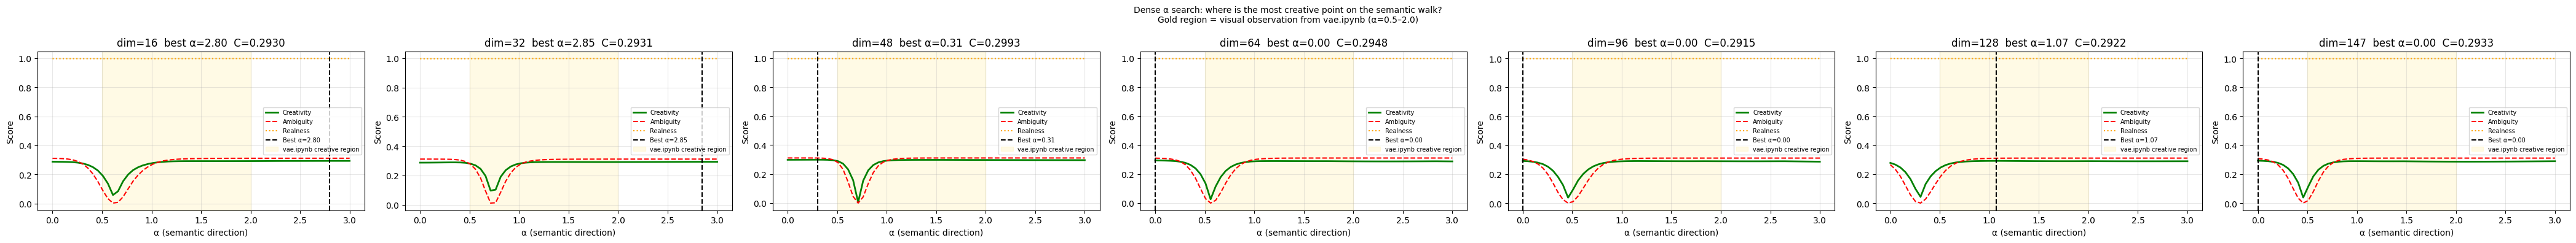

Saved -> alpha_search.png


In [64]:
# ─────────────────────────────────────────────────────────────
# Dense alpha search: find exact best creative position
# ─────────────────────────────────────────────────────────────

alphas_dense = torch.linspace(0.0, 3.0, 60)

search_results = {}
fig, axes = plt.subplots(1, len(DIMS_TO_TEST), figsize=(6*len(DIMS_TO_TEST), 4))

for col, dim in enumerate(DIMS_TO_TEST):
    wr  = walk_results[dim]
    vae = vaes[dim]

    # Generate all 60 alpha positions
    z_dense = torch.stack(
        [wr['anchor'] + a.item() * wr['step'] * wr['direction']
         for a in alphas_dense]).to(device)

    vae.eval()
    with torch.no_grad():
        imgs_dense = vae.decode(z_dense).cpu()

    c_d, n_d, r_d, a_d = score_creativity_extended(
        imgs_dense, clf, gen_ae, train_sub, device)

    best_idx   = c_d.argmax()
    best_alpha = alphas_dense[best_idx].item()
    best_z     = z_dense[best_idx]

    search_results[dim] = {
        'alphas': alphas_dense, 'c': c_d, 'r': r_d, 'a': a_d,
        'best_alpha': best_alpha, 'best_z': best_z,
        'best_img': imgs_dense[best_idx]
    }

    ax = axes[col] if len(DIMS_TO_TEST) > 1 else axes
    ax.plot(alphas_dense.numpy(), c_d, '-',  color='green',  label='Creativity', linewidth=2)
    ax.plot(alphas_dense.numpy(), a_d, '--', color='red',    label='Ambiguity',  linewidth=1.5)
    ax.plot(alphas_dense.numpy(), r_d, ':',  color='orange', label='Realness',   linewidth=1.5)
    ax.axvline(best_alpha, color='black', linestyle='--', linewidth=1.5,
                label=f'Best α={best_alpha:.2f}')
    ax.axvspan(0.5, 2.0, alpha=0.1, color='gold', label='vae.ipynb creative region')
    ax.set_xlabel('α (semantic direction)')
    ax.set_ylabel('Score')
    ax.set_title(f'dim={dim}  best α={best_alpha:.2f}  C={c_d.max():.4f}')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    print(f'dim={dim:<4}  best α={best_alpha:+.3f}  C={c_d.max():.4f}  '
          f'R={r_d[best_idx]:.4f}  A={a_d[best_idx]:.4f}')

plt.suptitle('Dense α search: where is the most creative point on the semantic walk?\n'
             'Gold region = visual observation from vae.ipynb (α=0.5–2.0)',
             fontsize=10)
plt.tight_layout()
plt.savefig('alpha_search.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> alpha_search.png')

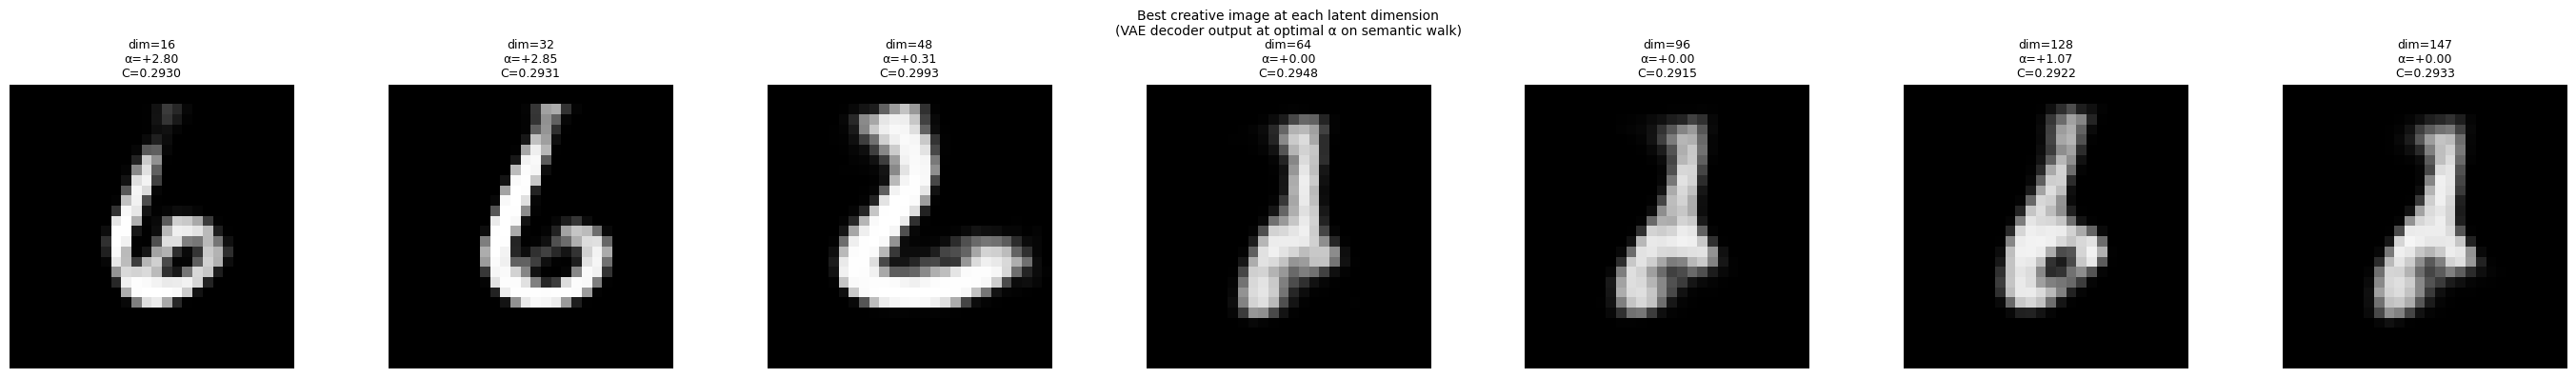

In [65]:
# ─────────────────────────────────────────────────────────────
# Show best image at each dimension side by side
# ─────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, len(DIMS_TO_TEST), figsize=(4*len(DIMS_TO_TEST), 4))
for col, dim in enumerate(DIMS_TO_TEST):
    sr  = search_results[dim]
    ax  = axes[col] if len(DIMS_TO_TEST) > 1 else axes
    ax.imshow(sr['best_img'][0], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'dim={dim}\nα={sr["best_alpha"]:+.2f}\nC={sr["c"].max():.4f}',
                  fontsize=9)
    ax.axis('off')
plt.suptitle('Best creative image at each latent dimension\n'
             '(VAE decoder output at optimal α on semantic walk)', fontsize=10)
plt.tight_layout()
plt.savefig('best_per_dim.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_540362/921096438.py:79: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load('saved_models_147d/px_unet_conditioned.pt', map_location=device))


Loaded px_unet_conditioned.pt  (1,257,025 params)


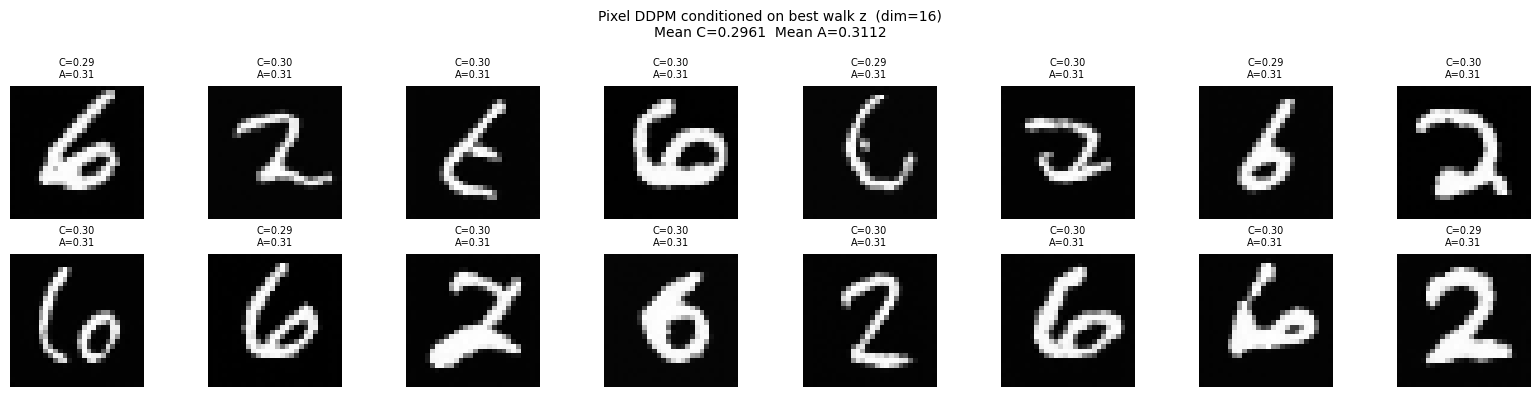

dim=16  C=0.2961  R=0.9926  A=0.3112


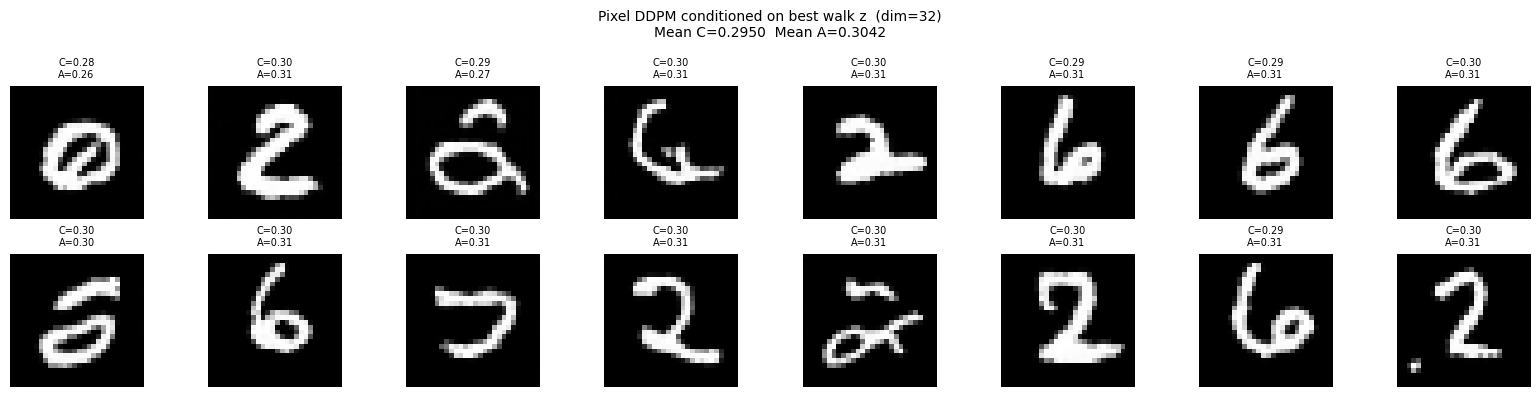

dim=32  C=0.2950  R=0.9932  A=0.3042


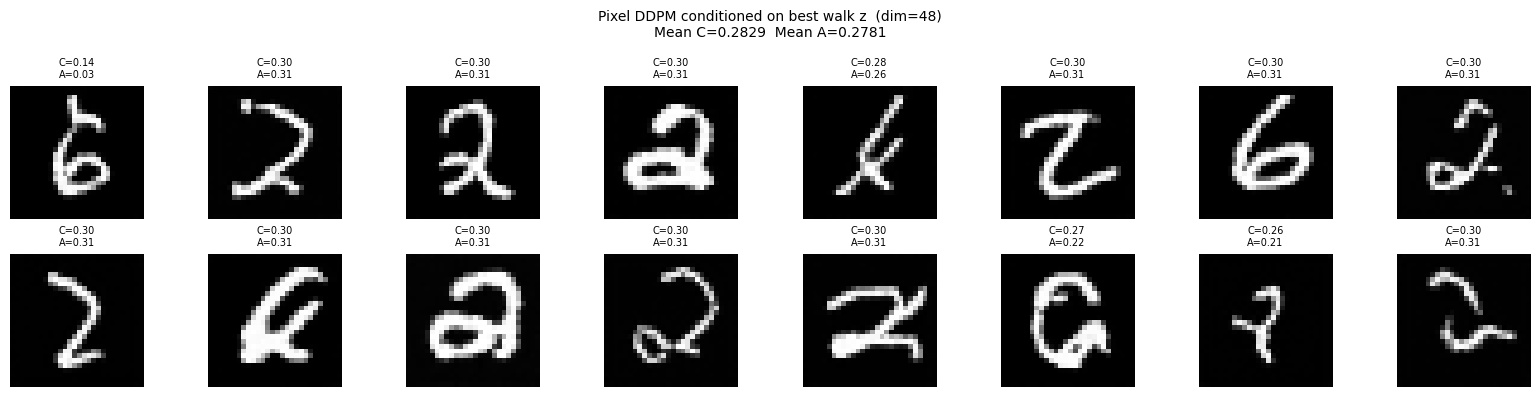

dim=48  C=0.2829  R=0.9898  A=0.2781


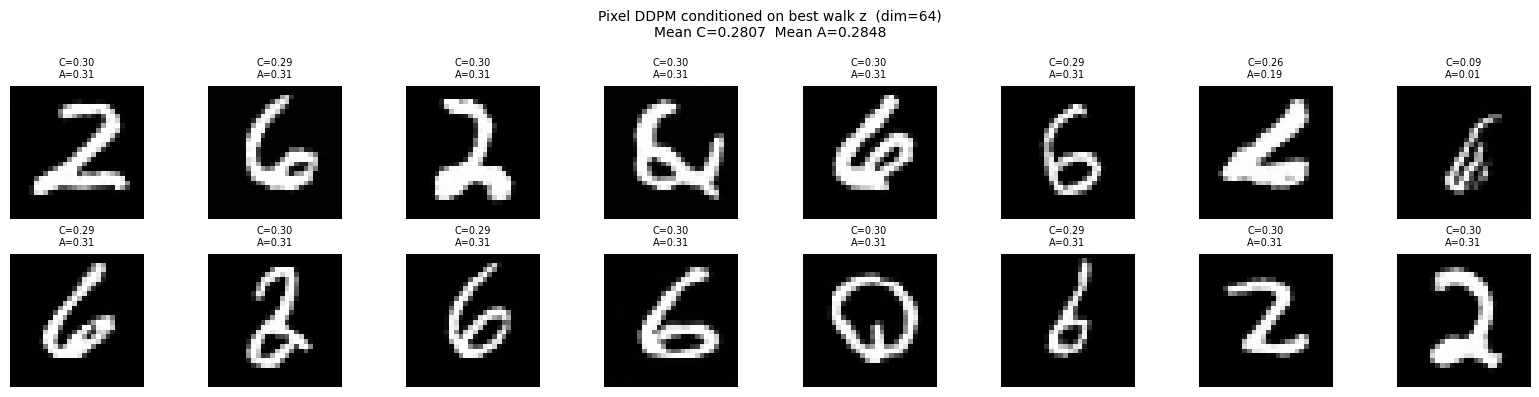

dim=64  C=0.2807  R=0.9926  A=0.2848


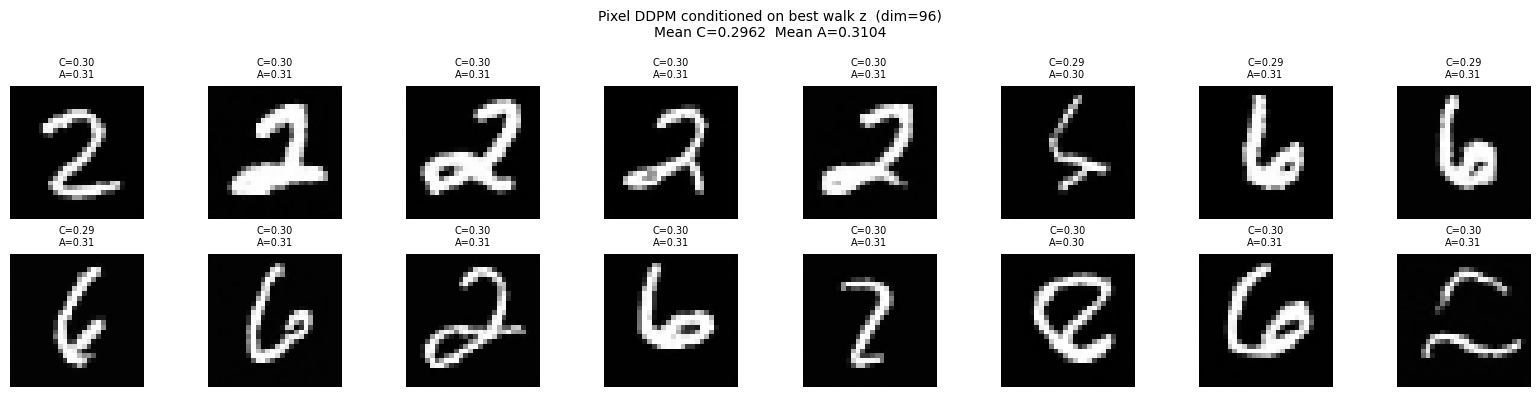

dim=96  C=0.2962  R=0.9924  A=0.3104


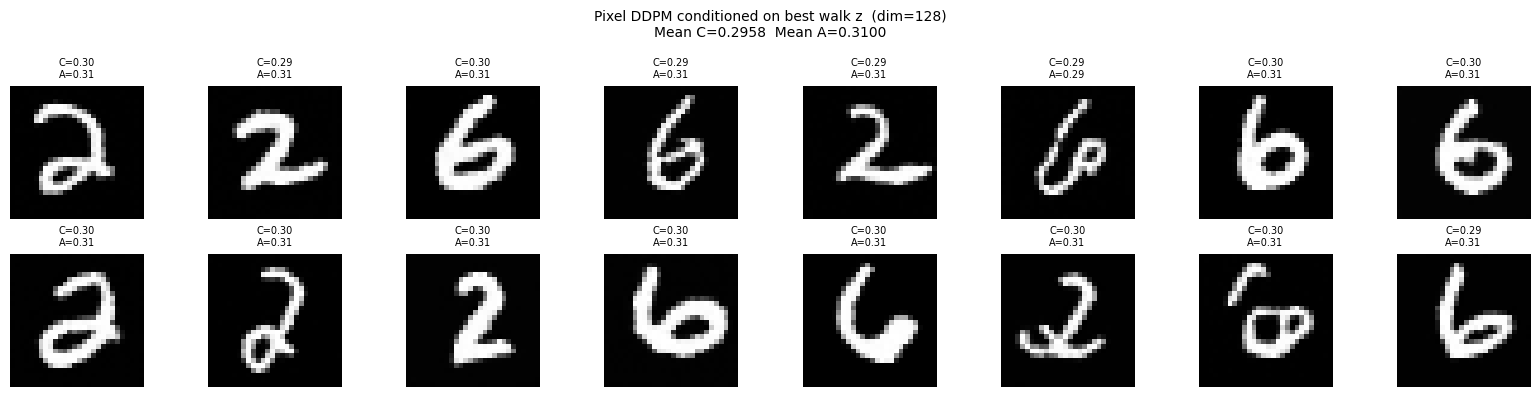

dim=128  C=0.2958  R=0.9926  A=0.3100


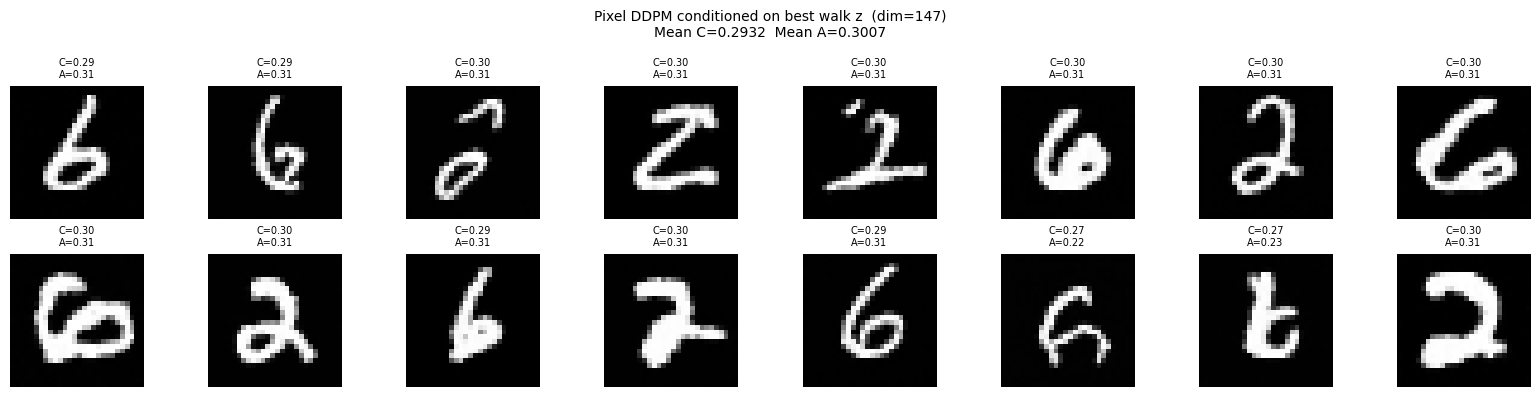

dim=147  C=0.2932  R=0.9924  A=0.3007


In [66]:
# ─────────────────────────────────────────────────────────────
# Load conditioned pixel U-Net and generate images from best z
# ─────────────────────────────────────────────────────────────

# ── Architecture (must match curved_manifold_walk_147d_v2.ipynb) ──

def get_num_groups(ch):
    for g in [32,16,8,4,2,1]:
        if ch % g == 0: return g
    return 1

class ResBlockCond(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, cond_dim=0):
        super().__init__()
        self.norm1     = nn.GroupNorm(get_num_groups(in_ch),  in_ch)
        self.conv1     = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2     = nn.GroupNorm(get_num_groups(out_ch), out_ch)
        self.conv2     = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_proj = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.cond_proj = nn.Sequential(nn.SiLU(), nn.Linear(cond_dim, out_ch)) \
                          if cond_dim > 0 else None
        self.skip      = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb, z_emb=None):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.time_proj(t_emb)[:,:,None,None]
        if self.cond_proj is not None and z_emb is not None:
            h = h + self.cond_proj(z_emb)[:,:,None,None]
        return self.conv2(F.silu(self.norm2(h))) + self.skip(x)

class CondUNetDenoiser(nn.Module):
    def __init__(self, in_channels=1, base_channels=32, time_dim=128, latent_cond_dim=147):
        super().__init__()
        C    = base_channels
        cond = latent_cond_dim
        self.time_embed  = nn.Sequential(
            SinusoidalTimeEmbed(time_dim),
            nn.Linear(time_dim, time_dim*2), nn.SiLU(),
            nn.Linear(time_dim*2, time_dim))
        self.latent_proj = nn.Sequential(
            nn.Linear(cond, time_dim), nn.SiLU(),
            nn.Linear(time_dim, time_dim)) if cond > 0 else None
        self.init_conv   = nn.Conv2d(in_channels, C, 3, padding=1)
        self.down1_res   = ResBlockCond(C,     C*2, time_dim, cond)
        self.down1_down  = nn.Conv2d(C*2, C*2, 3, stride=2, padding=1)
        self.down2_res   = ResBlockCond(C*2,   C*4, time_dim, cond)
        self.down2_down  = nn.Conv2d(C*4, C*4, 3, stride=2, padding=1)
        self.bottleneck  = ResBlockCond(C*4,   C*4, time_dim, cond)
        self.up1_up      = nn.ConvTranspose2d(C*4, C*4, 2, stride=2)
        self.up1_res     = ResBlockCond(C*4+C*4, C*2, time_dim, cond)
        self.up2_up      = nn.ConvTranspose2d(C*2, C*2, 2, stride=2)
        self.up2_res     = ResBlockCond(C*2+C*2, C,   time_dim, cond)
        self.out_norm    = nn.GroupNorm(get_num_groups(C), C)
        self.out_conv    = nn.Conv2d(C, in_channels, 3, padding=1)

    def forward(self, x, t, z_cond=None):
        t_emb = self.time_embed(t)
        if self.latent_proj is not None and z_cond is not None:
            t_emb = t_emb + self.latent_proj(z_cond)
        x     = self.init_conv(x)
        skip1 = self.down1_res(x,    t_emb, z_cond)
        x     = self.down1_down(skip1)
        skip2 = self.down2_res(x,    t_emb, z_cond)
        x     = self.down2_down(skip2)
        x     = self.bottleneck(x,   t_emb, z_cond)
        x     = self.up1_up(x)
        if x.shape[2:] != skip2.shape[2:]:
            x = F.interpolate(x, size=skip2.shape[2:], mode='nearest')
        x = self.up1_res(torch.cat([x, skip2], dim=1), t_emb, z_cond)
        x = self.up2_up(x)
        if x.shape[2:] != skip1.shape[2:]:
            x = F.interpolate(x, size=skip1.shape[2:], mode='nearest')
        x = self.up2_res(torch.cat([x, skip1], dim=1), t_emb, z_cond)
        return self.out_conv(F.silu(self.out_norm(x)))


# ── Load weights ───────────────────────────────────────────────
px_unet = CondUNetDenoiser(base_channels=32, time_dim=128, latent_cond_dim=32).to(device)
px_unet.load_state_dict(
    torch.load('saved_models_147d/px_unet_conditioned.pt', map_location=device))
px_unet.eval()
print(f'Loaded px_unet_conditioned.pt  '
      f'({sum(p.numel() for p in px_unet.parameters()):,} params)')

# ── Pixel DDPM scheduler (T=1000, matches training) ───────────
px_scheduler = DDPMScheduler(T=1000, beta_start=1e-4, beta_end=0.02).to(device)

def ddpm_to_01(x):
    return (x.clamp(-1,1) + 1) / 2

def sample_conditioned_pixel(px_unet, px_scheduler, z_cond,
                               guidance_scale=0.0, clf=None,
                               guide_every=10, device='cpu'):
    px_unet.eval()
    N = z_cond.size(0)
    x = torch.randn(N, 1, 28, 28, device=device)
    z = z_cond.to(device)
    for t in reversed(range(px_scheduler.T)):
        with torch.no_grad():
            t_vec    = torch.full((N,), t, device=device, dtype=torch.long)
            eps_pred = px_unet(x, t_vec, z)
        ab_t    = px_scheduler.alpha_bars[t]
        ab_prev = px_scheduler.alpha_bars_prev[t]
        beta_t  = px_scheduler.betas[t]
        x0_pred = ((x - torch.sqrt(1-ab_t)*eps_pred) / torch.sqrt(ab_t)).clamp(-1,1)
        coef1   = torch.sqrt(ab_prev) * beta_t / (1-ab_t)
        coef2   = torch.sqrt(px_scheduler.alphas[t]) * (1-ab_prev) / (1-ab_t)
        mean    = coef1 * x0_pred + coef2 * x
        if guidance_scale > 0 and clf is not None and t % guide_every == 0:
            mean_g = mean.detach().requires_grad_(True)
            x_01   = (mean_g.clamp(-1,1)+1)/2
            probs  = clf.probs(x_01)
            eps_   = 1e-8
            ambig  = -(probs[:,0]*torch.log(probs[:,0]+eps_) +
                       probs[:,1]*torch.log(probs[:,1]+eps_)).mean()
            grad   = torch.autograd.grad(ambig, mean_g)[0]
            grad   = grad / (grad.view(N,-1).norm(dim=-1).view(N,1,1,1)+1e-8)
            mean   = mean.detach() + guidance_scale * grad.detach()
        if t == 0:
            x = mean.detach()
        else:
            pvar = beta_t*(1-ab_prev)/(1-ab_t)
            x    = (mean + torch.sqrt(pvar.clamp(min=1e-20))*torch.randn_like(mean)).detach()
    return ddpm_to_01(x).cpu()


# ── Generate images from best z at each dimension ─────────────
# NOTE: px_unet was trained with 147-dim conditioning.
# For dim=16 and dim=32, we pad z to 147 dims with zeros
# so the conditioning is consistent with what the U-Net expects.

def pad_or_truncate_z(z, target_dim=32):
    current_dim = z.size(-1)
    if current_dim == target_dim:
        return z
    elif current_dim < target_dim:
        pad = torch.zeros(*z.shape[:-1], target_dim - current_dim, device=z.device)
        return torch.cat([z, pad], dim=-1)
    else:
        return z[..., :target_dim]


for dim in DIMS_TO_TEST:
    best_z  = search_results[dim]['best_z'].to(device)
    z_batch = pad_or_truncate_z(
        best_z.unsqueeze(0).expand(16, -1), target_dim=32)   # (16, 32)

    imgs_ddpm = sample_conditioned_pixel(
        px_unet, px_scheduler, z_batch,
        guidance_scale=0.0, device=device)

    c, n, r, a = score_creativity_extended(imgs_ddpm, clf, gen_ae, train_sub, device)

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(imgs_ddpm[i,0], cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'C={c[i]:.2f}\nA={a[i]:.2f}', fontsize=7)
        ax.axis('off')
    plt.suptitle(f'Pixel DDPM conditioned on best walk z  (dim={dim})\n'
                  f'Mean C={c.mean():.4f}  Mean A={a.mean():.4f}', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'pixel_ddpm_best_z_dim{dim}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'dim={dim}  C={c.mean():.4f}  R={r.mean():.4f}  A={a.mean():.4f}')

---
## Section 3 — Diffusion-Guided Geodesic with Training Data Attraction

The semantic walk is one-dimensional (movement along a single direction vector). The diffusion geodesic allows movement in any direction, guided by where real training data actually lives in latent space.

Each waypoint is pulled toward its nearest training latent code instead of toward the origin.

In [67]:
# ─────────────────────────────────────────────────────────────
# Diffusion geodesic with training data attraction
# ─────────────────────────────────────────────────────────────

def diffusion_geodesic(z_start, z_end, denoiser, scheduler,
                        train_latents_t,
                        n_waypoints=13, n_iters=200,
                        manifold_step=0.01, smooth_weight=0.5,
                        lambda_attract=0.1, t_frac=0.05,
                        device='cpu'):
    """
    Geodesic by alternating three steps:

    1. Training data attraction: pull each waypoint toward its nearest
       training latent code via torch.cdist. Directly keeps path on the
       real data manifold — not the prior N(0,I).

    2. Denoiser score: gentle nudge toward learned density (reduced from
       0.05 to 0.01 so it doesn't overpower attraction).

    3. Smoothness: pull each waypoint toward midpoint of its neighbors.
       Keeps path evenly spaced and prevents waypoints from collapsing.
    """
    z_s = z_start.detach().to(device)
    z_e = z_end.detach().to(device)
    train_latents_t = train_latents_t.to(device)

    alphas = torch.linspace(0, 1, n_waypoints).to(device)
    path   = torch.stack([(1-a)*z_s + a*z_e for a in alphas])
    path[0] = z_s; path[-1] = z_e

    denoiser.eval()
    for it in range(n_iters):
        interior = path[1:-1].clone()   # (N-2, latent_dim)

        # Step 1: Training data attraction
        dists    = torch.cdist(interior, train_latents_t)   # (N-2, M)
        nn_idx   = dists.argmin(dim=1)                      # (N-2,)
        nn_codes = train_latents_t[nn_idx]                  # (N-2, latent_dim)
        attract  = nn_codes - interior
        interior = interior + lambda_attract * attract

        # Step 2: Gentle denoiser score nudge
        score    = scheduler.denoise_score(denoiser, interior, t_frac=t_frac)
        interior = interior + manifold_step * score

        # Step 3: Smoothness
        path_new  = torch.cat([z_s.unsqueeze(0), interior, z_e.unsqueeze(0)])
        midpoints = 0.5 * (path_new[:-2] + path_new[2:])
        interior  = (1-smooth_weight)*interior + smooth_weight*midpoints

        path = torch.cat([z_s.unsqueeze(0), interior, z_e.unsqueeze(0)])

    return path.detach()


# Run geodesic at each dimension
geodesic_results = {}

for dim in DIMS_TO_TEST:
    vae  = vaes[dim]
    vae.eval()
    latent_mus    = vae._latent_mus
    latent_labels = vae._latent_labels

    mu2_centroid = latent_mus[latent_labels == 2].mean(0).to(device)
    mu6_centroid = latent_mus[latent_labels == 6].mean(0).to(device)

    print(f'\nRunning diffusion geodesic for dim={dim}...')
    z_geo = diffusion_geodesic(
        mu2_centroid, mu6_centroid,
        denoisers[dim], schedulers[dim],
        train_latents_t=vae._train_latents,
        n_waypoints=N_WALK_STEPS, n_iters=200,
        manifold_step=0.01, smooth_weight=0.5,
        lambda_attract=0.1, t_frac=0.05, device=device)

    with torch.no_grad():
        imgs_geo = vae.decode(z_geo).cpu()

    c_g, n_g, r_g, a_g = score_creativity_extended(
        imgs_geo, clf, gen_ae, train_sub, device)

    # NN distance for off-manifold measurement
    nbrs_lat = NearestNeighbors(n_neighbors=1).fit(latent_mus.numpy())
    nn_dist  = nbrs_lat.kneighbors(z_geo.cpu().numpy())[0][:,0]

    # Linear walk for comparison
    alphas_lin = torch.linspace(0,1,N_WALK_STEPS)
    z_lin = torch.stack([(1-a)*mu2_centroid + a*mu6_centroid
                          for a in alphas_lin]).to(device)
    with torch.no_grad():
        imgs_lin = vae.decode(z_lin).cpu()
    c_l, n_l, r_l, a_l = score_creativity_extended(
        imgs_lin, clf, gen_ae, train_sub, device)
    nn_dist_lin = nbrs_lat.kneighbors(z_lin.cpu().numpy())[0][:,0]

    geodesic_results[dim] = {
        'z_geo': z_geo, 'imgs_geo': imgs_geo,
        'c_geo': c_g, 'r_geo': r_g, 'a_geo': a_g, 'nn_geo': nn_dist,
        'z_lin': z_lin, 'imgs_lin': imgs_lin,
        'c_lin': c_l, 'r_lin': r_l, 'a_lin': a_l, 'nn_lin': nn_dist_lin,
        'mu2': mu2_centroid, 'mu6': mu6_centroid,
    }
    print(f'  Geodesic best: C={c_g.max():.4f} at step {c_g.argmax()}')
    print(f'  Linear best:   C={c_l.max():.4f} at step {c_l.argmax()}')
    print(f'  Geodesic mean NN dist: {nn_dist.mean():.3f}  '
          f'(linear: {nn_dist_lin.mean():.3f})')


Running diffusion geodesic for dim=16...
  Geodesic best: C=0.2962 at step 3
  Linear best:   C=0.2965 at step 6
  Geodesic mean NN dist: 0.878  (linear: 2.323)

Running diffusion geodesic for dim=32...
  Geodesic best: C=0.2962 at step 0
  Linear best:   C=0.2966 at step 8
  Geodesic mean NN dist: 1.173  (linear: 2.864)

Running diffusion geodesic for dim=48...
  Geodesic best: C=0.2972 at step 2
  Linear best:   C=0.2971 at step 8
  Geodesic mean NN dist: 1.185  (linear: 2.864)

Running diffusion geodesic for dim=64...
  Geodesic best: C=0.2962 at step 0
  Linear best:   C=0.2973 at step 8
  Geodesic mean NN dist: 1.371  (linear: 2.908)

Running diffusion geodesic for dim=96...
  Geodesic best: C=0.2969 at step 5
  Linear best:   C=0.2969 at step 8
  Geodesic mean NN dist: 1.760  (linear: 2.918)

Running diffusion geodesic for dim=128...
  Geodesic best: C=0.2967 at step 0
  Linear best:   C=0.2978 at step 8
  Geodesic mean NN dist: 1.812  (linear: 2.993)

Running diffusion geodesic

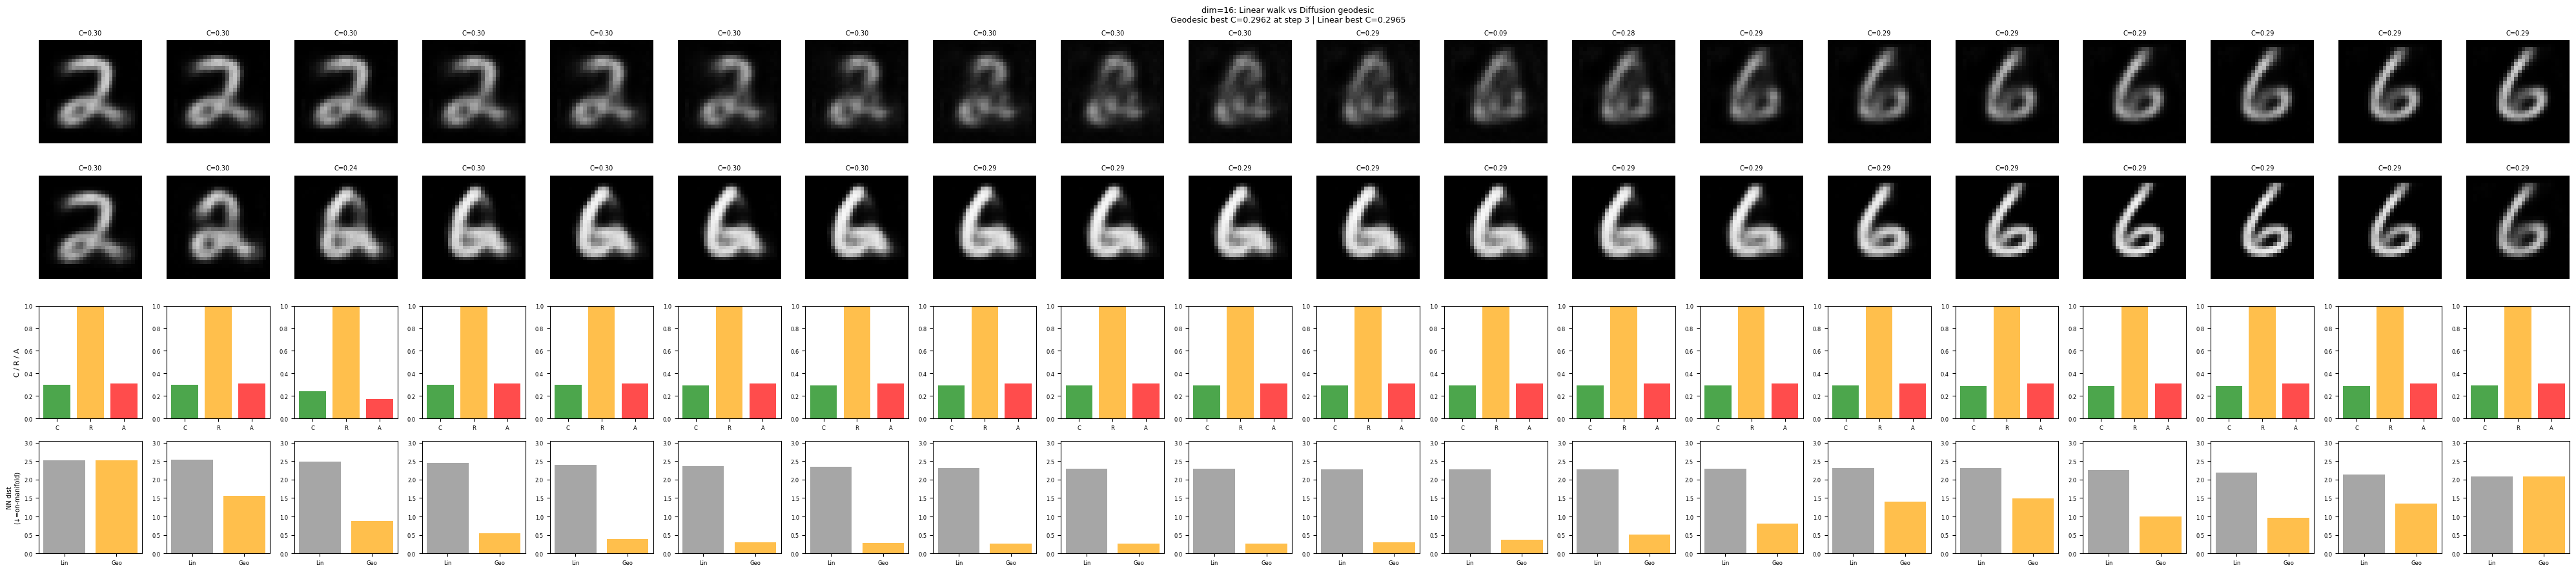

Saved -> geodesic_walk_dim16.png


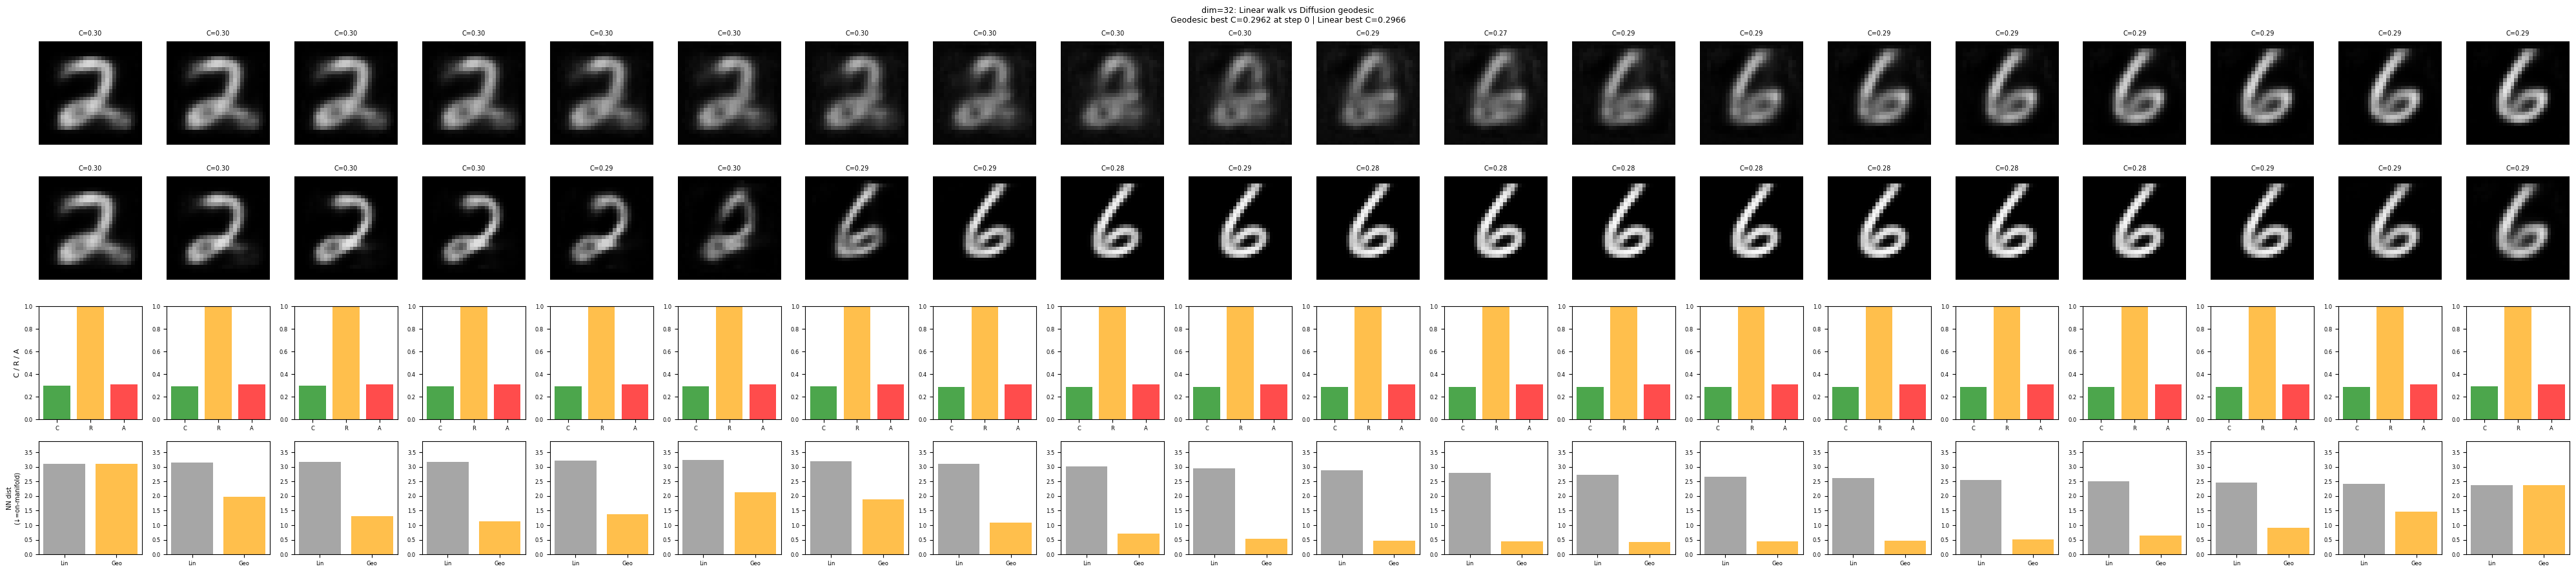

Saved -> geodesic_walk_dim32.png


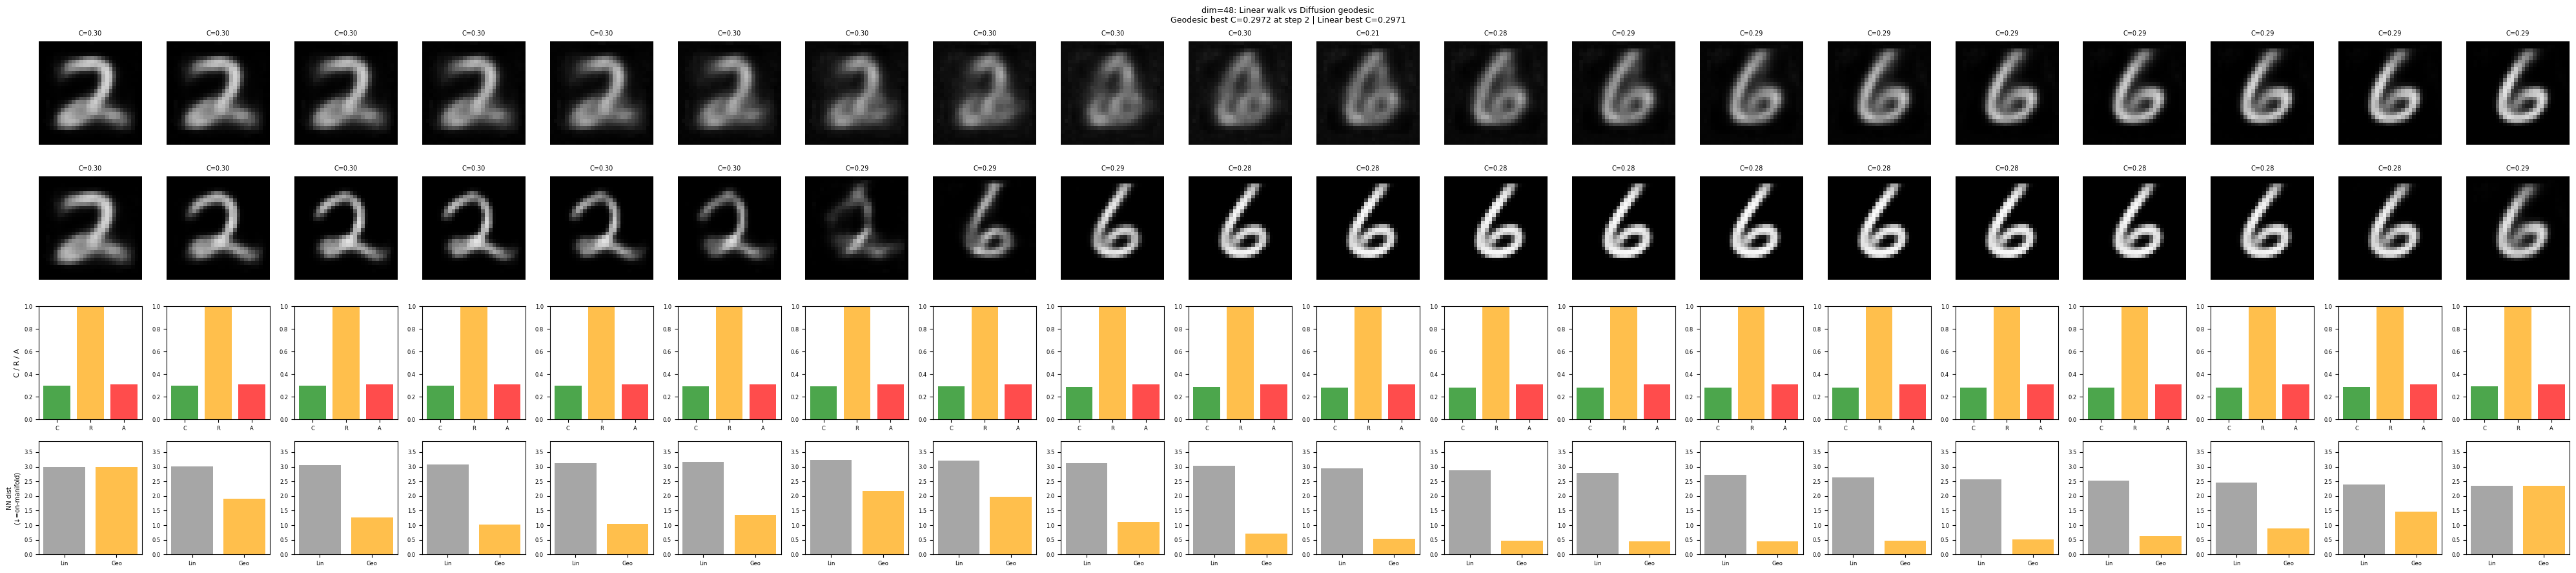

Saved -> geodesic_walk_dim48.png


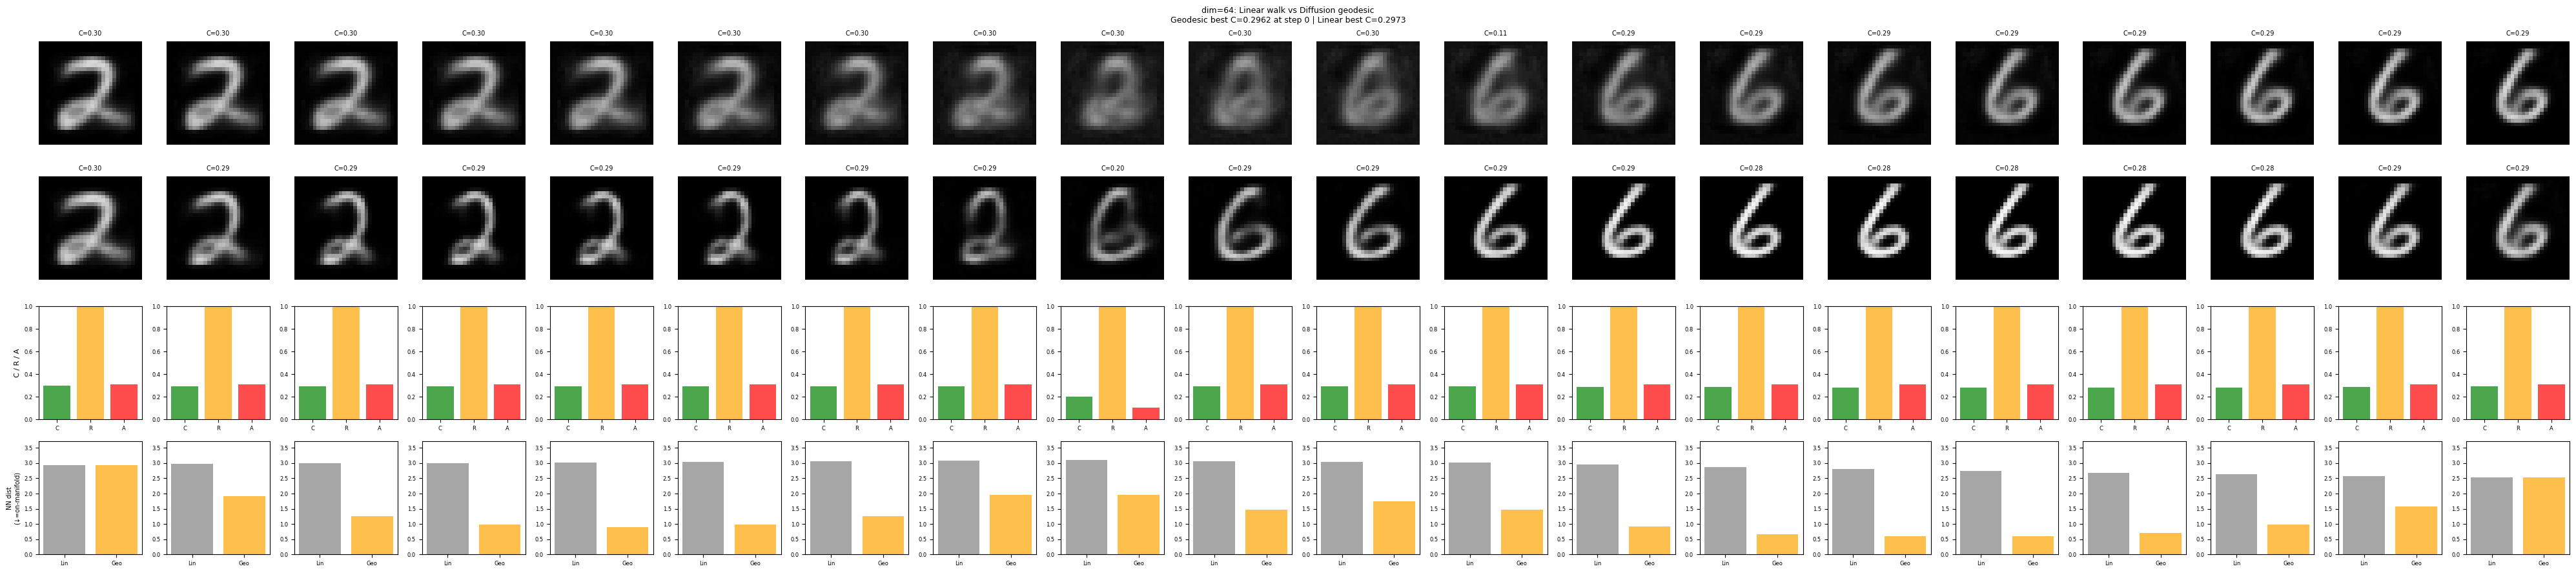

Saved -> geodesic_walk_dim64.png


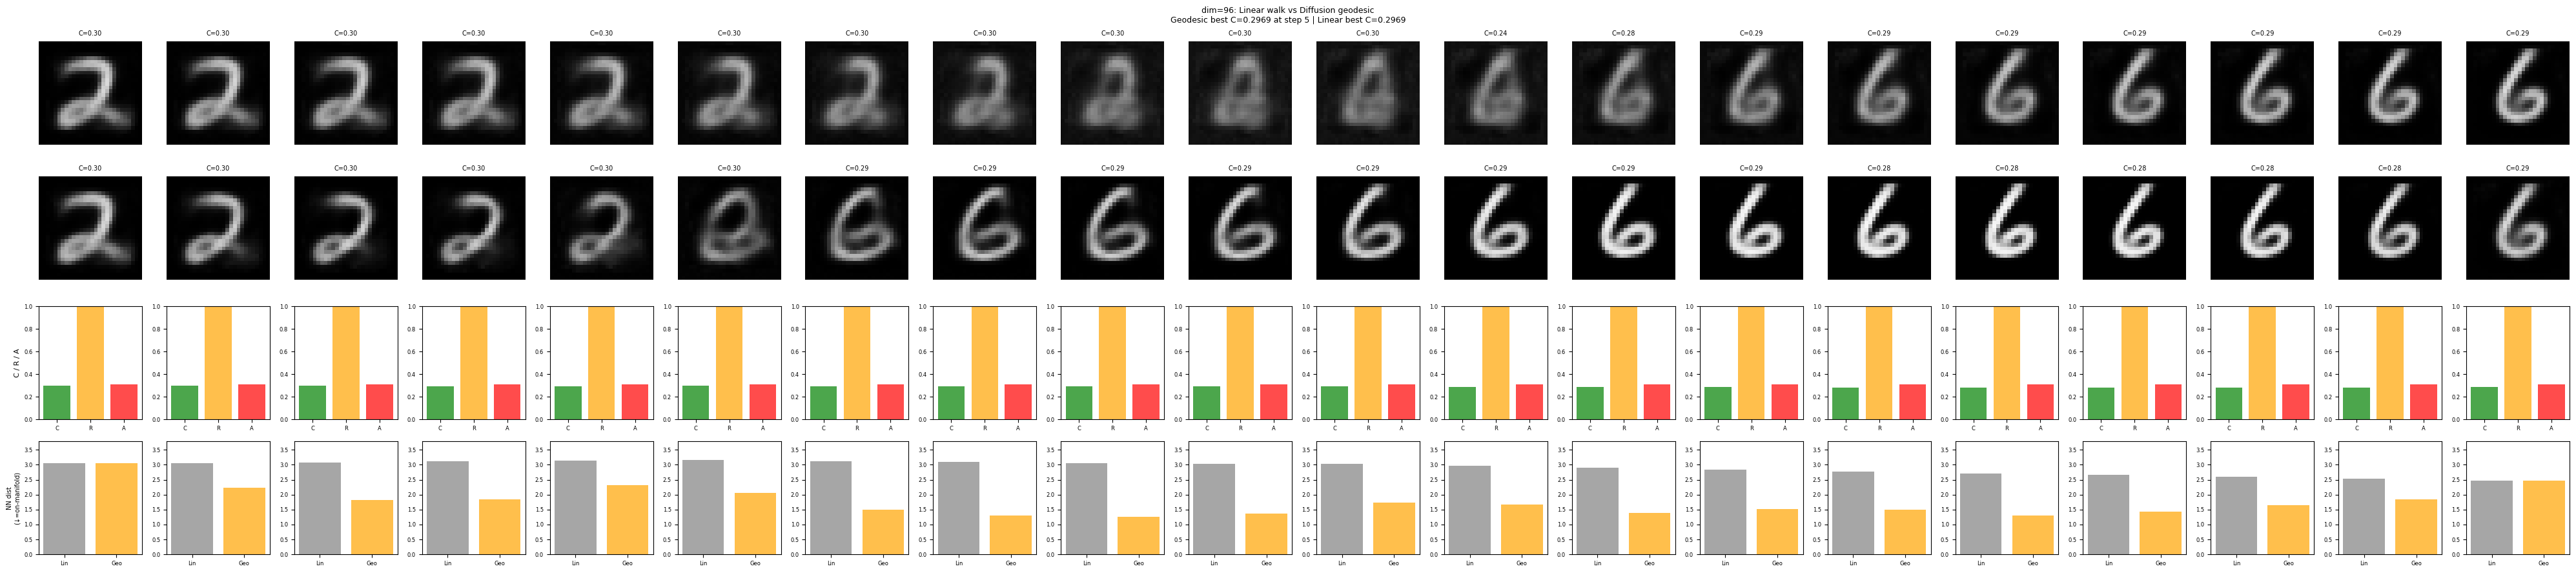

Saved -> geodesic_walk_dim96.png


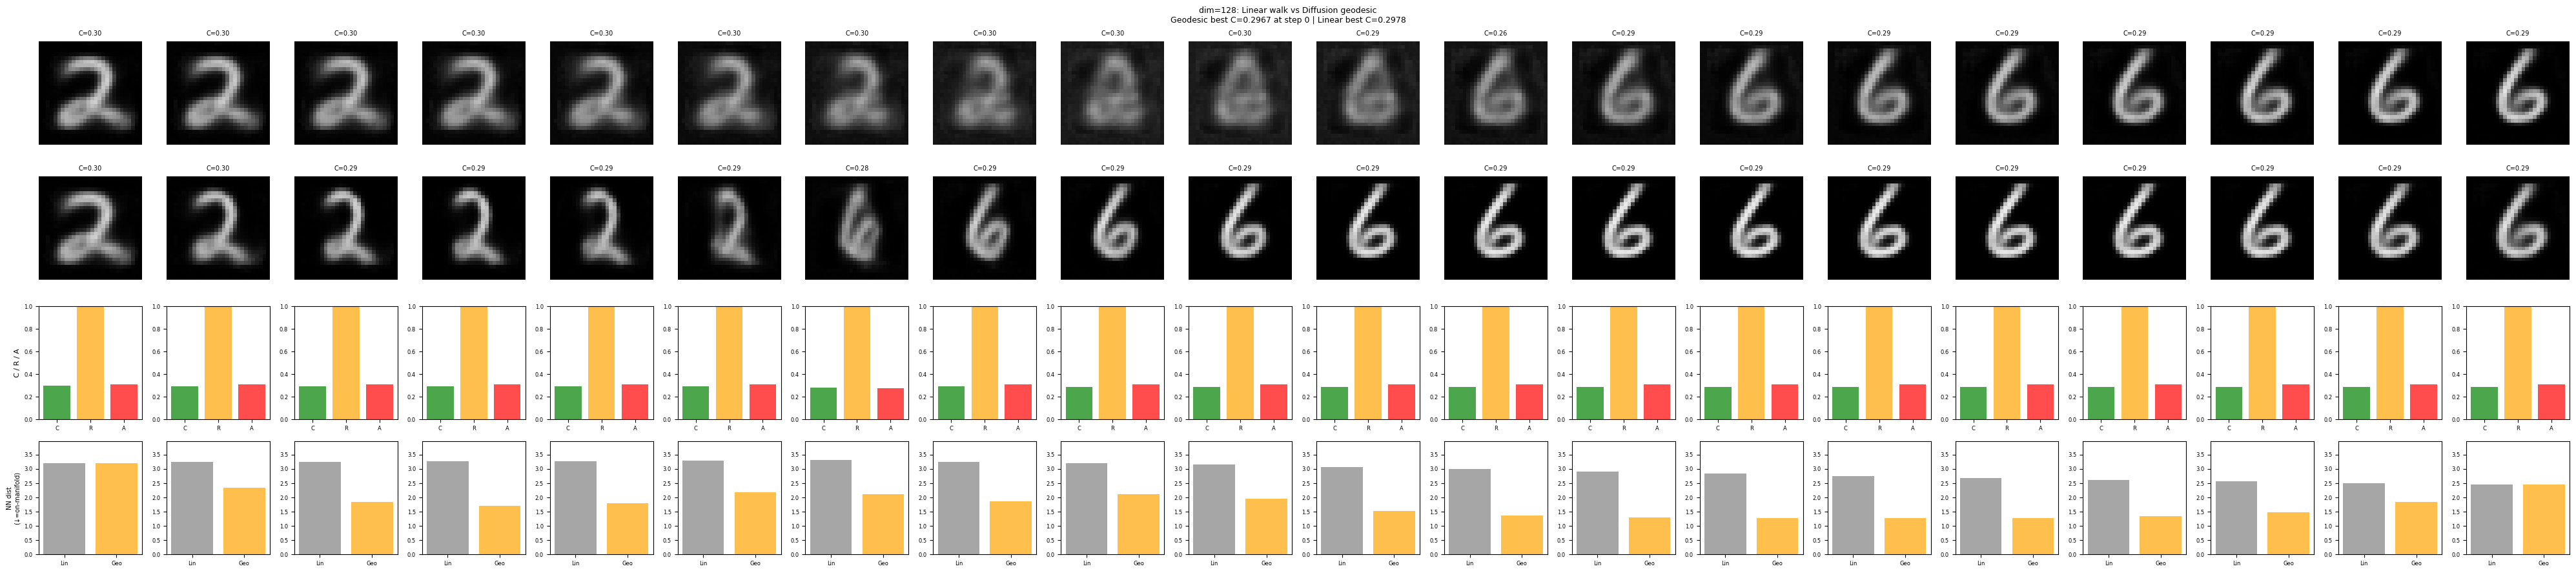

Saved -> geodesic_walk_dim128.png


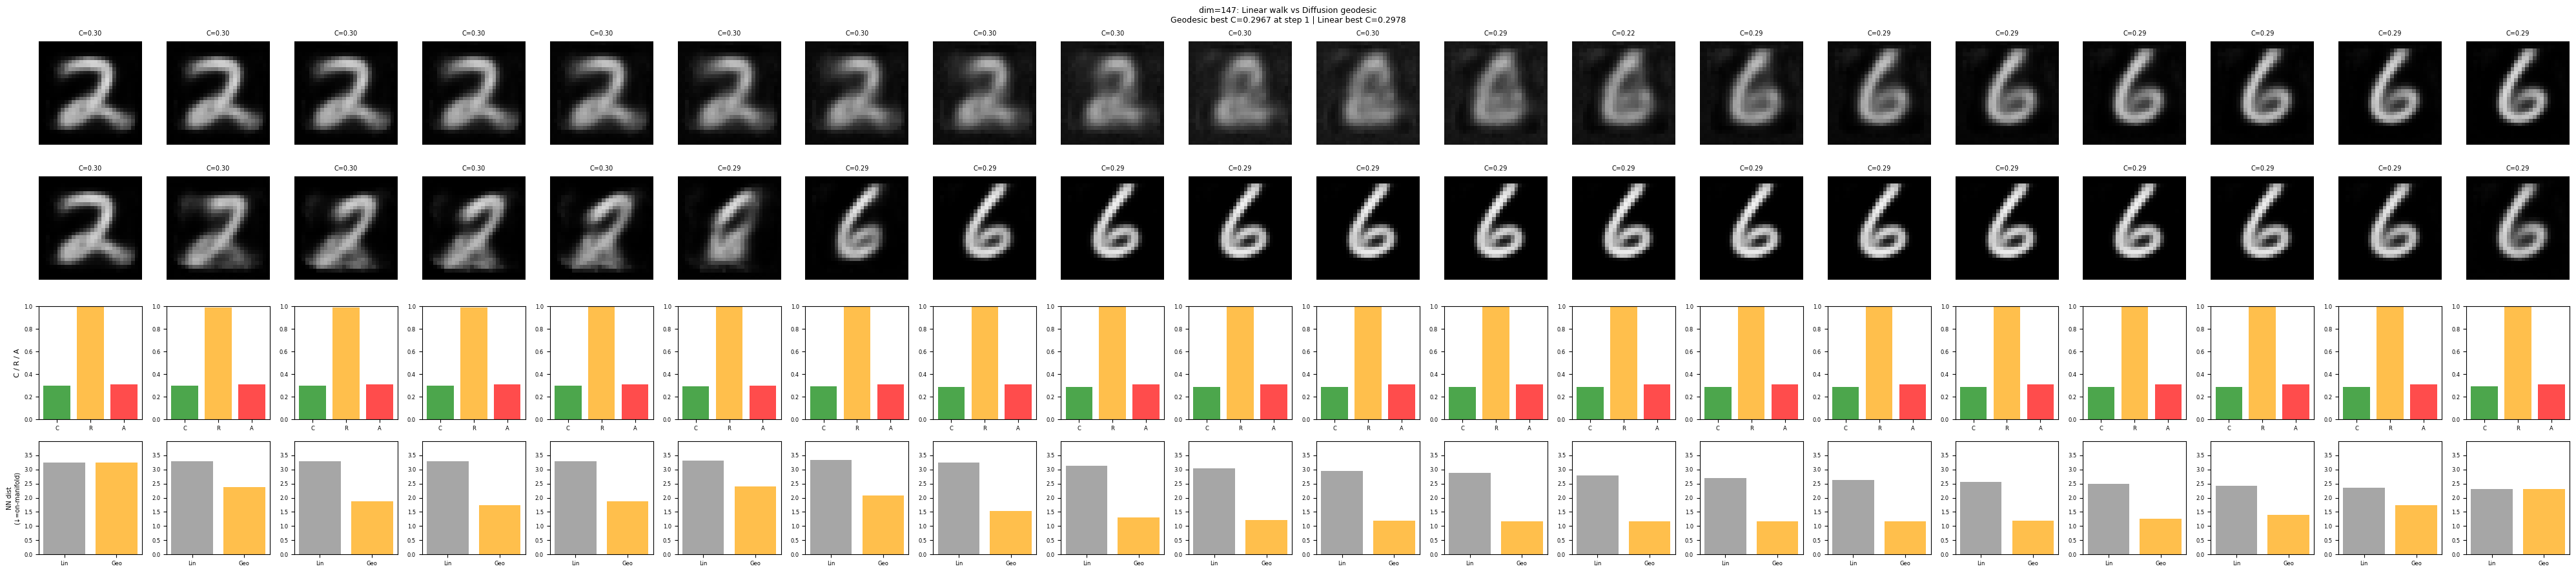

Saved -> geodesic_walk_dim147.png


In [68]:
# ─────────────────────────────────────────────────────────────
# Visualize: geodesic walk images + metrics for each dim
# ─────────────────────────────────────────────────────────────

for dim in DIMS_TO_TEST:
    gr   = geodesic_results[dim]
    c_g  = gr['c_geo']; r_g = gr['r_geo']; a_g = gr['a_geo']
    c_l  = gr['c_lin']; nn_g = gr['nn_geo']; nn_l = gr['nn_lin']
    imgs_g = gr['imgs_geo']; imgs_l = gr['imgs_lin']

    fig, axes = plt.subplots(4, N_WALK_STEPS, figsize=(2.0*N_WALK_STEPS, 9))
    max_nn = max(nn_g.max(), nn_l.max()) * 1.2

    for i in range(N_WALK_STEPS):
        # Row 0: linear walk image
        axes[0][i].imshow(imgs_l[i,0], cmap='gray', vmin=0, vmax=1)
        axes[0][i].set_title(f'C={c_l[i]:.2f}', fontsize=7); axes[0][i].axis('off')

        # Row 1: geodesic image
        axes[1][i].imshow(imgs_g[i,0], cmap='gray', vmin=0, vmax=1)
        axes[1][i].set_title(f'C={c_g[i]:.2f}', fontsize=7); axes[1][i].axis('off')

        # Row 2: creativity bars
        axes[2][i].bar(['C','R','A'], [c_g[i], r_g[i], a_g[i]],
                        color=['green','orange','red'], alpha=0.7)
        axes[2][i].set_ylim(0,1); axes[2][i].tick_params(labelsize=6)

        # Row 3: NN distance comparison
        axes[3][i].bar(['Lin','Geo'], [nn_l[i], nn_g[i]],
                        color=['gray','orange'], alpha=0.7)
        axes[3][i].set_ylim(0, max_nn); axes[3][i].tick_params(labelsize=6)

    axes[0][0].set_ylabel('Linear walk', fontsize=8)
    axes[1][0].set_ylabel('Diffusion geodesic', fontsize=8)
    axes[2][0].set_ylabel('C / R / A', fontsize=8)
    axes[3][0].set_ylabel('NN dist\n(↓=on-manifold)', fontsize=7)

    plt.suptitle(f'dim={dim}: Linear walk vs Diffusion geodesic\n'
                 f'Geodesic best C={c_g.max():.4f} at step {c_g.argmax()} | '
                 f'Linear best C={c_l.max():.4f}', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'geodesic_walk_dim{dim}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> geodesic_walk_dim{dim}.png')

---
## Section 4 — Shape Analysis

Verify that the best generated images have stroke structure between 2 and 6,
not just a high metric score.

HOG distance between class 2 and class 6: 0.1372


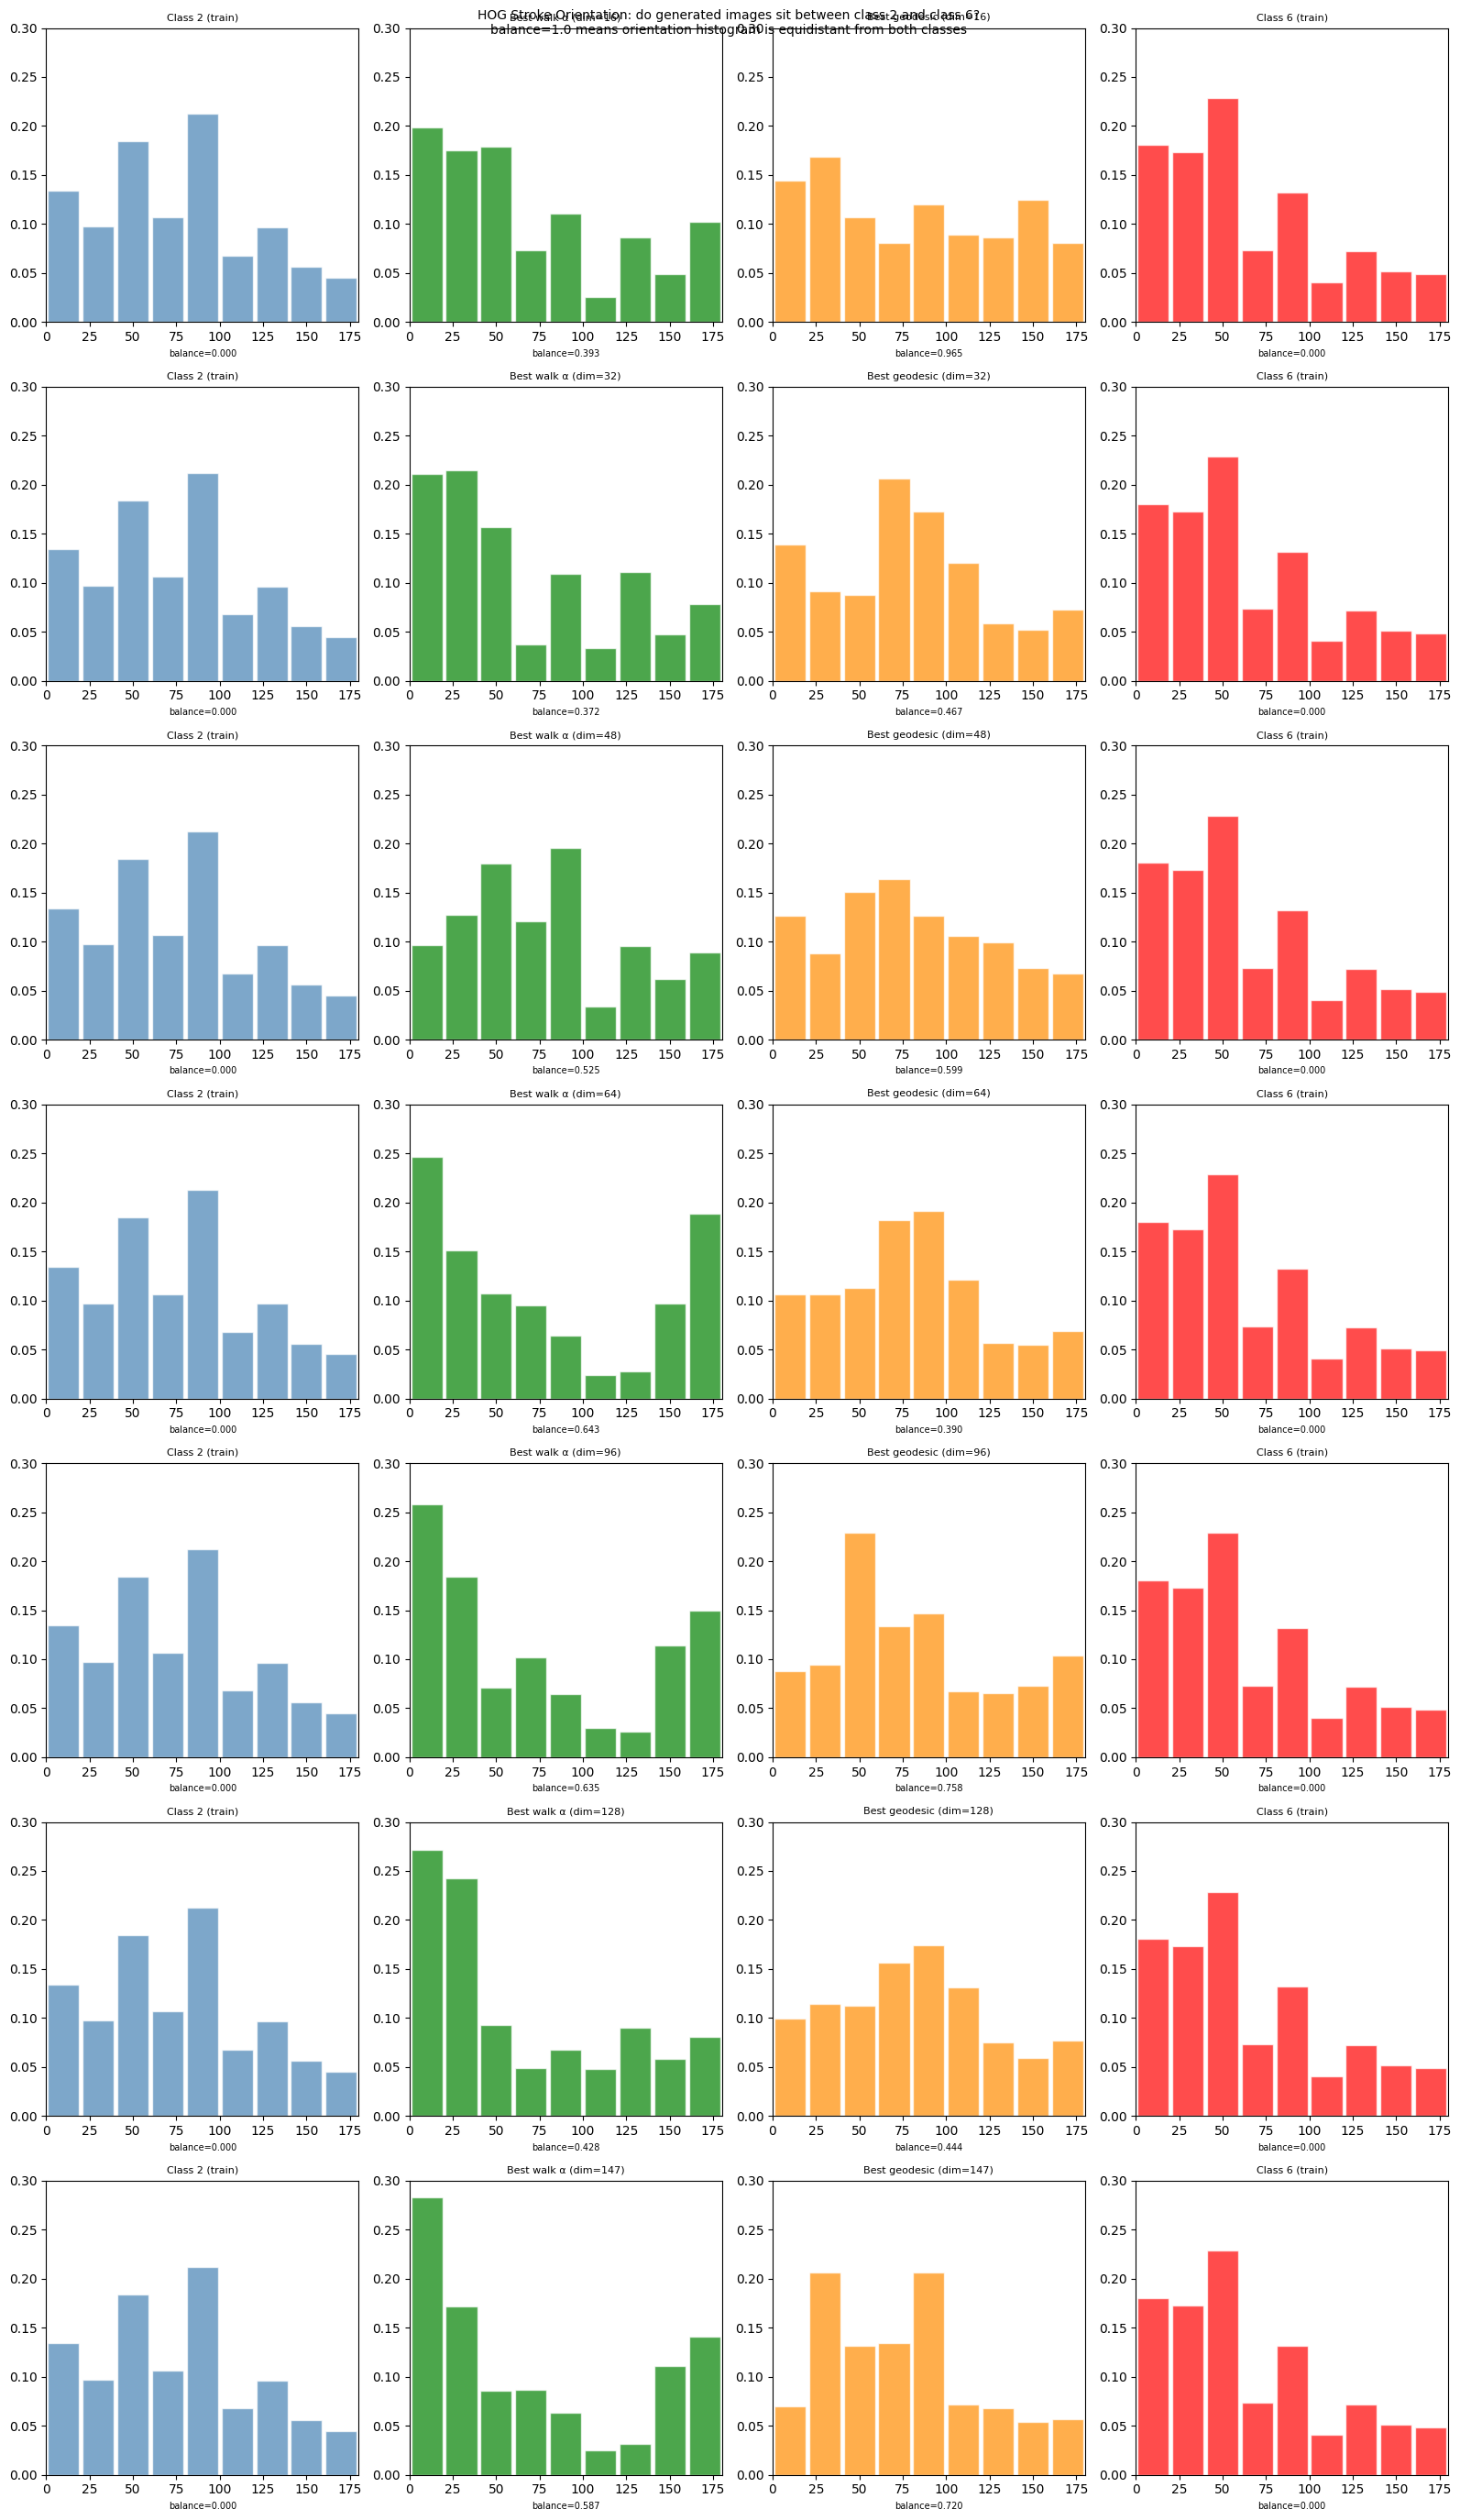

Saved -> hog_shape_analysis.png


In [69]:
# ─────────────────────────────────────────────────────────────
# HOG stroke orientation analysis
# ─────────────────────────────────────────────────────────────

def compute_hog(images_flat, n_bins=9):
    imgs = images_flat.reshape(-1, 28, 28)
    hists = []
    for img in imgs:
        gx = np.gradient(img, axis=1)
        gy = np.gradient(img, axis=0)
        mag = np.sqrt(gx**2 + gy**2)
        ori = np.arctan2(gy, gx) % np.pi
        hist, _ = np.histogram(ori.flatten(), bins=n_bins,
                                range=(0, np.pi), weights=mag.flatten())
        hists.append(hist / (hist.sum() + 1e-8))
    return np.array(hists)


# Compute class HOG profiles
mask2 = (train_labels == 2)
mask6 = (train_labels == 6)
hog_2    = compute_hog(train_flat[mask2]).mean(0)
hog_6    = compute_hog(train_flat[mask6]).mean(0)
dist_2_6 = np.linalg.norm(hog_2 - hog_6)
bins_deg = np.linspace(0, 180, 10)[:-1] + 10

print(f'HOG distance between class 2 and class 6: {dist_2_6:.4f}')

# HOG for best creative image at each dim (semantic walk and geodesic)
fig, all_axes = plt.subplots(len(DIMS_TO_TEST), 4, figsize=(16, 4*len(DIMS_TO_TEST)))

for row, dim in enumerate(DIMS_TO_TEST):
    # Best from semantic walk
    best_walk_img = search_results[dim]['best_img'].view(1,-1).numpy()
    hog_walk      = compute_hog(best_walk_img).mean(0)

    # Best from geodesic
    c_g = geodesic_results[dim]['c_geo']
    best_geo_img = geodesic_results[dim]['imgs_geo'][c_g.argmax()].view(1,-1).numpy()
    hog_geo      = compute_hog(best_geo_img).mean(0)

    for col, (hog, label, color) in enumerate([
        (hog_2,    'Class 2 (train)',    'steelblue'),
        (hog_walk, f'Best walk α (dim={dim})', 'green'),
        (hog_geo,  f'Best geodesic (dim={dim})', 'darkorange'),
        (hog_6,    'Class 6 (train)',    'red'),
    ]):
        ax = all_axes[row][col]
        ax.bar(bins_deg, hog, width=18, color=color, alpha=0.7, edgecolor='white')
        ax.set_xlim(0, 180); ax.set_ylim(0, 0.30)
        ax.set_xlabel('Orientation (°)', fontsize=7)
        ax.set_title(label, fontsize=8)
        # Balance score
        d2 = np.linalg.norm(hog - hog_2)
        d6 = np.linalg.norm(hog - hog_6)
        bal = 1 - abs(d2-d6) / (dist_2_6 + 1e-8)
        ax.set_xlabel(f'balance={bal:.3f}', fontsize=7)

plt.suptitle('HOG Stroke Orientation: do generated images sit between class 2 and class 6?\n'
             'balance=1.0 means orientation histogram is equidistant from both classes',
             fontsize=10)
plt.tight_layout()
plt.savefig('hog_shape_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> hog_shape_analysis.png')

H1 lifetime — class 2: 0.3560  class 6: 0.2553  ideal midpoint: 0.3056
  dim=16  geodesic H1 lifetimes: ['0.058', '0.048', '0.039', '0.032', '0.033', '0.033', '0.033', '0.033', '0.033', '0.032', '0.031', '0.031', '0.030', '0.031', '0.029', '0.036', '0.037', '0.037', '0.038', '0.031']
  dim=32  geodesic H1 lifetimes: ['0.069', '0.060', '0.060', '0.055', '0.047', '0.045', '0.046', '0.043', '0.043', '0.040', '0.039', '0.038', '0.038', '0.038', '0.038', '0.038', '0.038', '0.035', '0.039', '0.036']
  dim=48  geodesic H1 lifetimes: ['0.056', '0.043', '0.053', '0.053', '0.049', '0.042', '0.040', '0.036', '0.040', '0.039', '0.034', '0.033', '0.031', '0.031', '0.031', '0.031', '0.033', '0.034', '0.035', '0.037']
  dim=64  geodesic H1 lifetimes: ['0.062', '0.056', '0.056', '0.053', '0.048', '0.048', '0.048', '0.043', '0.035', '0.043', '0.048', '0.042', '0.042', '0.036', '0.034', '0.034', '0.034', '0.034', '0.038', '0.036']
  dim=96  geodesic H1 lifetimes: ['0.044', '0.060', '0.058', '0.052', '0.

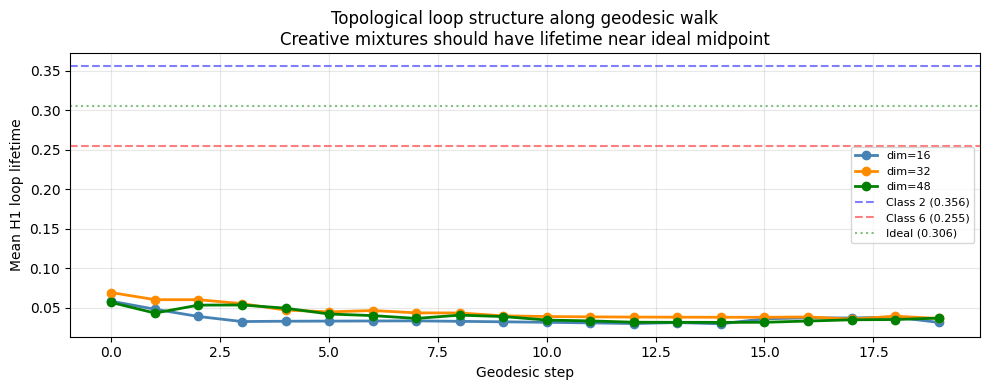

In [70]:
# ─────────────────────────────────────────────────────────────
# H1 Persistent homology
# ─────────────────────────────────────────────────────────────

if TOPO_AVAILABLE:
    def h1_lifetime(img_flat):
        cc  = gudhi.CubicalComplex(dimensions=[28,28],
                                    top_dimensional_cells=img_flat.tolist())
        cc.compute_persistence()
        dgm = cc.persistence_intervals_in_dimension(1)
        if len(dgm) == 0: return 0.0
        finite = dgm[np.isfinite(dgm[:,1])]
        return float((finite[:,1]-finite[:,0]).mean()) if len(finite) > 0 else 0.0

    # Class reference lifetimes
    lt_2 = np.mean([h1_lifetime(train_flat[i]) for i in np.where(mask2)[0][:100]])
    lt_6 = np.mean([h1_lifetime(train_flat[i]) for i in np.where(mask6)[0][:100]])
    lt_ideal = 0.5*(lt_2 + lt_6)
    print(f'H1 lifetime — class 2: {lt_2:.4f}  class 6: {lt_6:.4f}  ideal midpoint: {lt_ideal:.4f}')

    topo_results = {}
    for dim in DIMS_TO_TEST:
        # Geodesic walk lifetimes
        imgs_g_flat = geodesic_results[dim]['imgs_geo'].view(-1,784).numpy()
        lifetimes   = [h1_lifetime(imgs_g_flat[i]) for i in range(N_WALK_STEPS)]
        topo_results[dim] = lifetimes
        print(f'  dim={dim}  geodesic H1 lifetimes: {[f"{x:.3f}" for x in lifetimes]}')

    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['steelblue','darkorange','green']
    for dim, col in zip(DIMS_TO_TEST, colors):
        ax.plot(topo_results[dim], 'o-', color=col, label=f'dim={dim}', linewidth=2)
    ax.axhline(lt_2,     color='blue',  linestyle='--', alpha=0.5, label=f'Class 2 ({lt_2:.3f})')
    ax.axhline(lt_6,     color='red',   linestyle='--', alpha=0.5, label=f'Class 6 ({lt_6:.3f})')
    ax.axhline(lt_ideal, color='green', linestyle=':',  alpha=0.5, label=f'Ideal ({lt_ideal:.3f})')
    ax.set_xlabel('Geodesic step'); ax.set_ylabel('Mean H1 loop lifetime')
    ax.set_title('Topological loop structure along geodesic walk\n'
                  'Creative mixtures should have lifetime near ideal midpoint')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('h1_topology.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('H1 topology skipped. pip install gudhi persim')

---
## Section 5 — Final Comparison Across Dimensions



  Method                                     Best C   Best R   Best A
  -------------------------------------------------------------------------
  Semantic walk (dim=16)                0.2930   0.9978   0.3113
  Geodesic (dim=16)                    0.2962   0.9951   0.3112
  Semantic walk (dim=32)                0.2931   0.9980   0.3113
  Geodesic (dim=32)                    0.2962   0.9942   0.3113
  Semantic walk (dim=48)                0.2993   0.9972   0.3109
  Geodesic (dim=48)                    0.2972   0.9974   0.3113
  Semantic walk (dim=64)                0.2948   0.9977   0.3104
  Geodesic (dim=64)                    0.2962   0.9939   0.3113
  Semantic walk (dim=96)                0.2915   0.9977   0.3039
  Geodesic (dim=96)                    0.2969   0.9937   0.3109
  Semantic walk (dim=128)               0.2922   0.9981   0.3104
  Geodesic (dim=128)                   0.2967   0.9926   0.3113
  Semantic walk (dim=147)               0.2933   0.9978   0.3079
  Geodesic (di

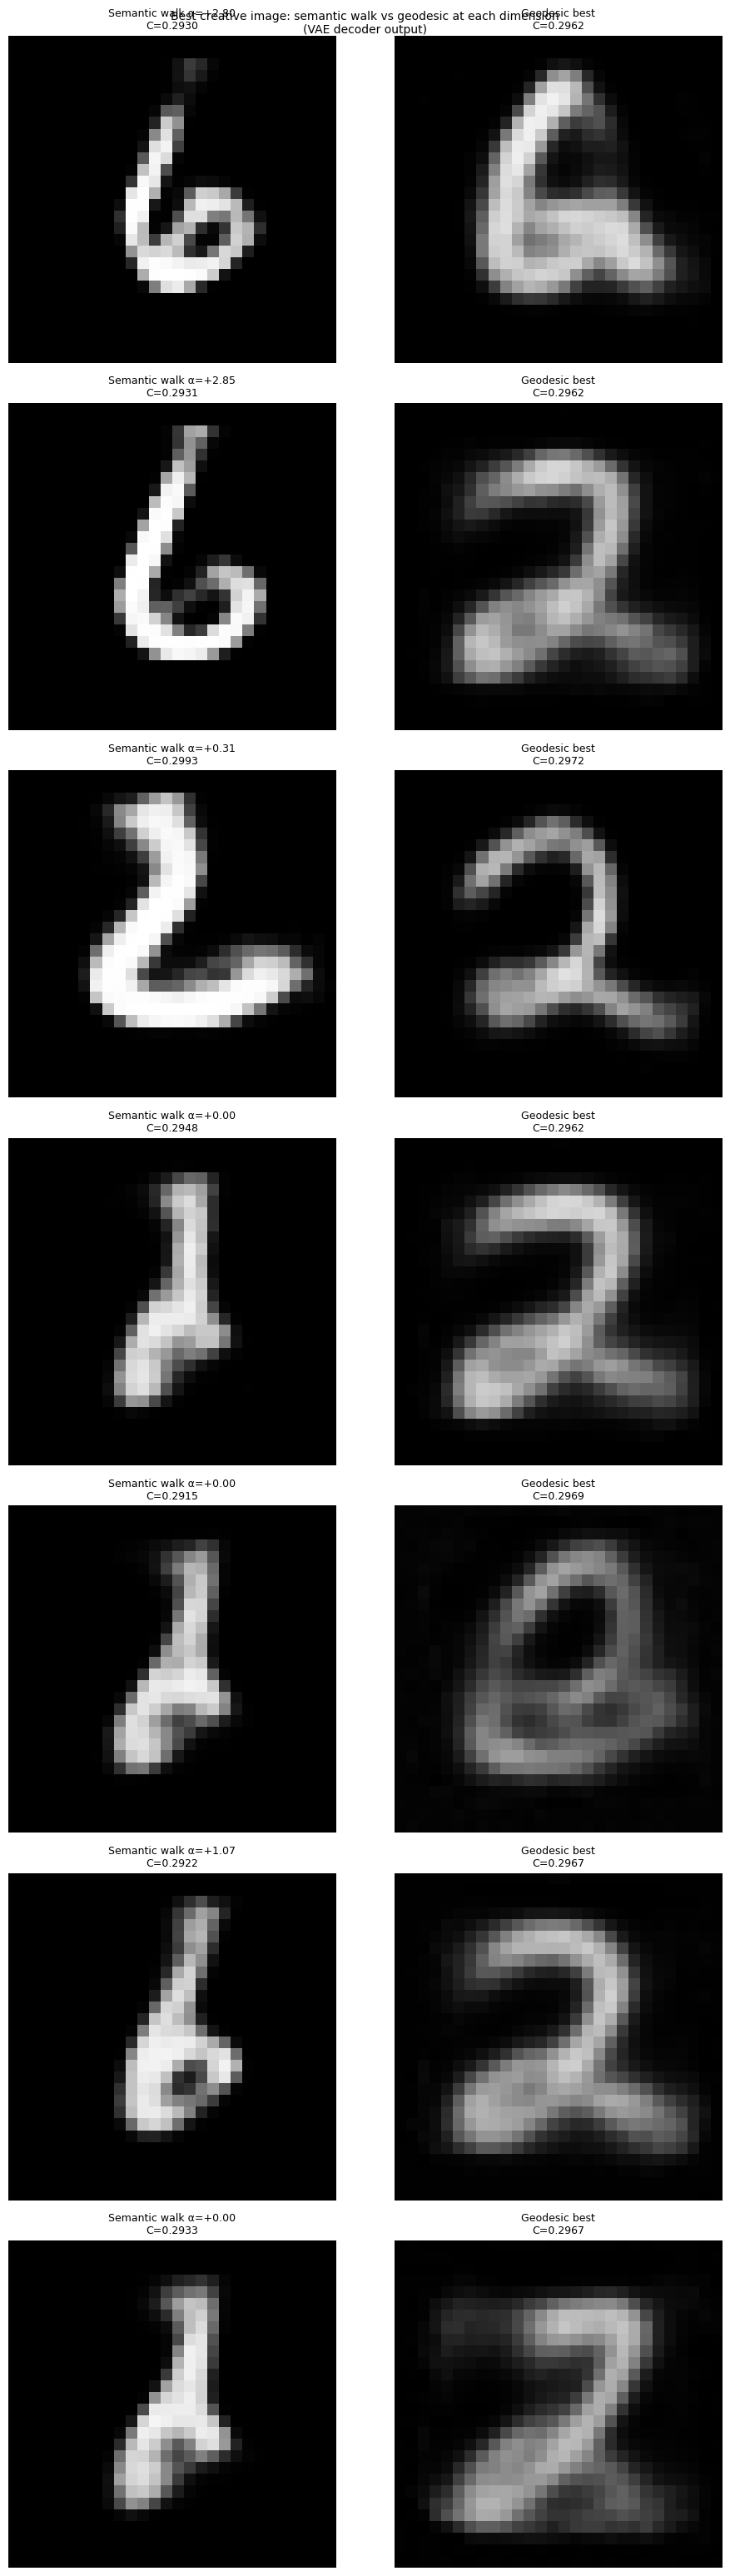

Saved -> final_comparison.png


In [71]:
# ─────────────────────────────────────────────────────────────
# Summary table and best images across all methods and dims
# ─────────────────────────────────────────────────────────────

print('\n' + '='*75)
print(f'  {"Method":<40} {"Best C":>8} {"Best R":>8} {"Best A":>8}')
print('  ' + '-'*73)

for dim in DIMS_TO_TEST:
    # Semantic walk
    sr = search_results[dim]
    bi = sr['c'].argmax()
    print(f'  Semantic walk (dim={dim}){" "*(16-len(str(dim)))}'
          f'{sr["c"].max():>8.4f} {sr["r"][bi]:>8.4f} {sr["a"][bi]:>8.4f}')

    # Geodesic
    gr = geodesic_results[dim]
    bg = gr['c_geo'].argmax()
    print(f'  Geodesic (dim={dim}){" "*(20-len(str(dim)))}'
          f'{gr["c_geo"].max():>8.4f} {gr["r_geo"][bg]:>8.4f} {gr["a_geo"][bg]:>8.4f}')

print('='*75)

# Visual grid: best image from each method and dimension
n_methods = 2   # semantic walk, geodesic
fig, axes = plt.subplots(len(DIMS_TO_TEST), n_methods, figsize=(5*n_methods, 4.5*len(DIMS_TO_TEST)))

for row, dim in enumerate(DIMS_TO_TEST):
    sr = search_results[dim]
    gr = geodesic_results[dim]

    for col, (img, c_score, title) in enumerate([
        (sr['best_img'][0], sr['c'].max(), f'Semantic walk α={sr["best_alpha"]:+.2f}'),
        (gr['imgs_geo'][gr['c_geo'].argmax(),0], gr['c_geo'].max(), 'Geodesic best'),
    ]):
        ax = axes[row][col]
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'{title}\nC={c_score:.4f}', fontsize=9)
        ax.axis('off')
    axes[row][0].set_ylabel(f'dim={dim}', fontsize=11, rotation=0,
                              ha='right', va='center', labelpad=40)

plt.suptitle('Best creative image: semantic walk vs geodesic at each dimension\n'
             '(VAE decoder output)', fontsize=10)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> final_comparison.png')

In [72]:
# ─────────────────────────────────────────────────────────────
# Save models and results
# ─────────────────────────────────────────────────────────────

os.makedirs('saved_models_v3', exist_ok=True)

for dim in DIMS_TO_TEST:
    torch.save(vaes[dim].state_dict(),      f'saved_models_v3/vae_{dim}d.pt')
    torch.save(denoisers[dim].state_dict(), f'saved_models_v3/denoiser_{dim}d.pt')

# Save best z vectors for each dim (for Haoting's policy network)
best_zs = {}
for dim in DIMS_TO_TEST:
    gr = geodesic_results[dim]
    sr = search_results[dim]
    best_zs[dim] = {
        'z_geodesic_best': gr['z_geo'][gr['c_geo'].argmax()].cpu(),
        'z_walk_best':     sr['best_z'].cpu(),
        'best_alpha':      sr['best_alpha'],
    }
torch.save(best_zs, 'saved_models_v3/best_z_vectors.pt')

print('Saved to saved_models_v3/')
for f in sorted(os.listdir('saved_models_v3')):
    size = os.path.getsize(f'saved_models_v3/{f}') / 1e6
    print(f'  {f}  ({size:.1f} MB)')

Saved to saved_models_v3/
  best_z_vectors.pt  (0.0 MB)
  denoiser_128d.pt  (3.0 MB)
  denoiser_147d.pt  (3.0 MB)
  denoiser_16d.pt  (2.5 MB)
  denoiser_32d.pt  (2.6 MB)
  denoiser_48d.pt  (2.6 MB)
  denoiser_64d.pt  (2.7 MB)
  denoiser_96d.pt  (2.8 MB)
  vae_128d.pt  (3.1 MB)
  vae_147d.pt  (3.2 MB)
  vae_16d.pt  (2.6 MB)
  vae_32d.pt  (2.7 MB)
  vae_48d.pt  (2.7 MB)
  vae_64d.pt  (2.8 MB)
  vae_96d.pt  (3.0 MB)
